# <font color='steelblue'>Introducción al aprendizaje automático</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 17/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color="steelblue">Descripción y Configuración del cuaderno</font>


**Descripción:** En este cuaderno se hace una introducción al aprendizaje automático. Descubrirás en qué consiste, qué tipo de problemas resuelve, cómo se trabajan y evalúan las soluciones obtenidas, y cuáles son los principales retos que enfrenta la aplicación de este tipo de técnicas.


In [1]:
# @title Cargar módulos
# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math
import random                 # importamos módulo para cáculos matemáticos
from io import StringIO
import sys

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white') # Changed from sns.set() to sns.set_style('white')
%config InlineBackend.figure_format = 'retina'

# <font color="steelblue">1. ¿Qué es el aprendizaje automático?</font>

Vivimos en la era de las máquinas inteligentes. En la última década, los sistemas basados en el aprendizaje automático han pasado, de vencer a los mejores jugadores de ajedrez, a influir en la mayoría de nuestras decisiones diarias, como hacen los sistemas de recomendación que encontramos en servicios de streaming como Netflix y Youtube.

Como habitantes del siglo XXI queremos responder a las preguntas que quizá alguna vez te has hecho: qué es el aprendizaje automático, y por qué te recomendamos estudiarlo. Trataremos de mostrarte qué tipo de problemas resuelve y cuándo es apropiado o no utilizar esta tecnología.  

El aprendizaje automático es un nuevo paradigma de programación en el que, en lugar de programar explícitamente los ordenadores para que realicen algunas tareas, dejamos que aprendan de los datos para encontrar los patrones subyacentes en ellos. En pocas palabras, el aprendizaje automático es la ciencia, o la tecnología, que da a la máquina la capacidad de aprender de los datos.

Este tipo de aprendizaje está intrínsecamente relacionado con el análisis de datos y la estadística. En general, las técnicas de aprendizaje automático son métodos basados en aprovechar al máximo la información disponible en los datos, y para ello utilizan computación y procedimientos informáticos, junto con conceptos y técnicas de estadística, probabilidad y optimización.

El objetivo del aprendizaje automático, la minería de datos o la inteligencia artificial es facilitarnos la vida: automatizar tareas y utilizar la información disponible para tomar mejores decisiones.

En la programación ordinaria, el trabajo del programador consiste en escribir detalladamente cada una de las reglas que componen la tarea a realizar sobre los datos existentes.

El aprendizaje automático invierte esta situación. Se utilizan los datos y los resultados (o clasificaciones, también llamadas *etiquetas*) para generar reglas con las que predecir cómo se relacionan entre sí o qué patrones siguen, y poder aplicar esas reglas a otros datos para predecir sus resultados y comportamientos.

Tomemos un ejemplo del mundo real. Si queremos crear una aplicación que, a partir de una foto de una persona, pueda determinar si lleva o no una mascarilla, abasteceremos al modelo de aprendizaje automático con un buen número de imágenes de personas con y sin mascarilla, cada una de ellas convenientemente identificada (etiquetada); el modelo derivará (aprenderá) las reglas o patrones que relacionan las imágenes con el hecho de llevar o no una mascarilla. Posteriormente se podrán utilizar esas reglas para reconocer mascarillas en otras imágenes distintas (que no fueron usadas por el modelo) para las que no tenemos una identificación dada (etiqueta).

Abordar un problema de reconocimiento de imágenes con programación basada en reglas a definir sería realmente difícil, considerando que hay distintos tipos de máscaras, colores, e infinidad de escenarios posibles sobre los que poder reconocer si hay mascarilla, y dónde empieza y acaba una. Con el aprendizaje automático sólo será necesario un buen número de imágenes de personas con y sin mascarilla, en las que previamente de modo manual hayamos identificado si está o no presente la mascarilla. De ahí estaremos a pocos pasos de conseguir un reconocedor eficaz de máscaras faciales, utilizando técnicas de aprendizaje automático.

# <font color="steelblue">2. Problemas típicos en aprendizaje automático</font>

El aprendizaje automático ha transformado muchos sectores, desde la banca, la fabricación, el streaming, los vehículos autónomos, la agricultura, etc. De hecho, la mayoría de los productos y servicios tecnológicos que utilizamos a diario poseen algún tipo de algoritmo de aprendizaje automático en su interior.

Estos son los casos de uso más comunes del aprendizaje automático:

* **Sistemas de recomendación**. Prácticamente todos los sitios web recopilan información de sus clientes (*cookies*) para identificar perfiles en función de su comportamiento e intereses al navegar, y ofrecerles, en consecuencia, recomendaciones y anuncios personalizados. Lo mismo ocurre con servicios de streaming como YouTube y Netflix, o de compras como Amazon.

* **Detección de fraudes** en tiempo real, que pueden utilizar los bancos y otras organizaciones financieras, a partir de información sobre las transacciones y referentes de fraude previo.

* **Predicción del reembolso de préstamos** a partir de los datos históricos de los clientes bancarios, para predecir -con antelación a la concesión- si un sujeto concreto será capaz de devolver el crédito.

* **Diagnóstico de enfermedades y predicción de la tasa de supervivencia**. El aprendizaje automático está encontrando cada vez más valor en la medicina. Puede ayudar a los profesionales a diagnosticar enfermedades en unos pocos minutos a través de técnicas de reconocimiento de imágenes (con rayos X, TAC,...) o patrones obtenidos de resultados analíticos, a evaluar para un sujeto la probabilidad de sufrir una enfermedad, predecir su evolución, o calcular la probabilidad de sobrevivir cierto tiempo, etc..

* **Aplicaciones en la industria**. Algunas empresas de fabricación han automatizado la tarea de inspección y utilizan la visión artificial para revisar los productos en busca de defectos, lo que permite reajustar y mejorar los procesos de modo semi-automático, y en última instancia acelerar la producción y reducir costes. En [2020 State of AI-Based Machine Vision by Landing AI](https://landing.ai/wp-content/uploads/2020/11/MachineVisionSurvey.pdf) se dan más evidencias de las mejoras que genera el uso de la inteligencia artificial en la industria.

* **Predicción de bajas**. Las empresas de servicios pueden utilizar el aprendizaje automático para predecir el riesgo de que un cliente cancele su cuenta o suscripción, y en consecuencia ayudarles a definir estrategias con las que mejoren la experiencia de usuario y consigan retener mejor a sus clientes. Algo similar se aplica en las plataformas de gestión del aprendizaje, para identificar, en función de su comportamiento, estudiantes con riesgo de fracasar, y proponer con ello estrategias alternativas de aprendizaje que garanticen su éxito académico.

* **Detección de spam** en el correo electrónico. Casi todos los proveedores tienen la capacidad de detectar el spam de los correos electrónicos entrantes para proteger a los usuarios de promociones falsas y estafas. Este filtrado está basado en aprendizaje automático.

* **Vehículos autónomos** actuales utilizan sistemas de aprendizaje automático y aprendizaje profundo para navegar por las carreteras. Utilizando la visión por ordenador, pueden ser capaces de detectar peatones, vehículos, semáforos, así como señales y otros objetos circundantes.

* **Clasificación de textos o documentos**. Con el aprendizaje automático es viable identificar el tema del que se trata en un texto o documento, o determinar, por ejemplo, si el contenido de una página web es inapropiado o demasiado explícito. Esto tiene múltiples aplicaciones en ámbitos en los que se trabaja con un volumen documental considerable, como auditorías, abogacía, seguridad pública, ...

* **Procesamiento del lenguaje natural (PLN)**. Cada día es más común que nuestro procesador de textos nos sugiera palabras con las que continuar el discurso, o correcciones ortográficas o sintácticas. Estos recursos son resultados de algoritmos de aprendizaje automático para el etiquetado de partes del discurso, el reconocimiento de entidades con nombre, el análisis sintáctico libre de contexto o el análisis sintáctico de dependencias. Se trata de problemas de aprendizaje más ricos, conocidos como "*problemas de predicción estructurada*".

* **Aplicaciones de procesamiento del habla**, que incluyen el reconocimiento y síntesis del habla, la identificación de hablantes. Se conocen como técnicas de modelado del lenguaje y de modelado acústico.

* **Aplicaciones de visión por ordenador**, como el reconocimiento e identificación de objetos, la detección de rostros, el reconocimiento óptico de caracteres en imágenes (*OCR, Optical Character Recognition*), la recuperación de imágenes basada en el contenido, o la estimación de la postura.

* **Aplicaciones de biología computacional** como la predicción de la función de las proteínas, la identificación de puntos clave en el metabolismo celular, o el análisis de redes de genes y proteínas.

Hay muchas más aplicaciones del aprendizaje automático, pero la lista podría resultar infinita. Esta introducción esperamos que haya servido para percibir, a *grosso modo*, el potencial del aprendizaje automático en el mundo actual.



## <font color="steelblue">Cuándo usar y no usar el aprendizaje automático</font>

El aprendizaje automático es una tecnología increíble y ha demostrado muchos éxitos en la resolución de diversos problemas del mundo real. Sin embargo, como cualquier otra tecnología, no es adecuado para resolver todo tipo de problemas. Por lo tanto, es igual de importante saber cuándo utilizarlo y cuándo no.

**¿Cuándo utilizar el aprendizaje automático?**

Este tipo de aprendizaje es preferible cuando se abordan:

* Problemas que son demasiado complejos para ser resueltos con programación ordinaria, como por ejemplo el reconocimiento de rostros o la detección de correos spam, donde es excesivamente complejo confeccionar todas las reglas de inclusión/exclusión.

* Problemas que implican el razonamiento visual y la comprensión del lenguaje, como el reconocimiento de imágenes, el reconocimiento del habla, la traducción automática, etc. Como veremos más adelante, los problemas de percepción a gran escala o los problemas visuales y de lenguaje suelen ser manejados por sistemas de aprendizaje profundo.

* Procesos que cambian rápidamente, cuyas características evolucionan con el tiempo, y donde es necesario que el sistema siga funcionando bien. El aprendizaje automático es adecuado para este tipo de problemas porque estos algoritmos pueden reentrenarse continuamente con datos e ir aprendiendo cómo se producen los cambios.

* Los problemas que son claros y tienen objetivos sencillos: como responder una pregunta de sí/no, clasificar a un sujeto como enfermo/no enfermo, predecir una cifra en base a un histórico (como la cantidad de electricidad que se consumirá en un día).


Dicho esto, **¿cuándo es poco recomendable utilizar el aprendizaje automático?** Pues por ejemplo en:

* Problemas de predicción en los que precisas conocer el efecto concreto que tienen ciertas variables condicionantes sobre una respuesta. La mayoría de los modelos de aprendizaje automático se consideran cajas negras y no proporcionan reglas fijas para describir cómo es la relación entre distintas variables.

* Problemas de predicción de fenómenos variables y cambiantes con el tiempo y aquellos que no siguen patrones preestablecidos fijos. Por ejemplo, el comportamiento de la bolsa, que si bien tiene ciertos patrones identificados, su capacidad de fluctuar e invertir de repente una tendencia dada es un fenómeno frecuente.

* Problemas que puedan ser resueltos con programación ordinaria o con métodos heurísticos simples.

* Problemas que requieren de una solución única y estable que no precisa ser actualizada. Si no va a ser posible capturar de modo continuado información con la que abastecer, reentrenar los modelos y actualizar las predicciones realizadas por los modelos de aprendizaje automático, carece de sentido utilizarlos. Es preferible acudir a modelos estadísticos clásicos estáticos.

El aprendizaje automático sigue transformando procesos que nunca se imaginaron, y sin lugar a dudas continuará creciendo y aplicándose en más y más ámbitos y problemas.

# <font color="steelblue">3. Tipos de aprendizaje automático</font>

En líneas generales, existen 5 tipos principales de sistemas de aprendizaje automático, que son:

* Aprendizaje supervisado
* Aprendizaje no supervisado
* Aprendizaje semi-supervisado
* Aprendizaje auto-supervisado
* Aprendizaje por refuerzo

Vamos a repasar todos estos tipos para conseguir una comprensión alta de lo que realmente significan.

## <font color='steelblue'>Aprendizaje supervisado

La mayoría de las tareas de aprendizaje automático pertenecen al tipo de aprendizaje supervisado. Un modelo de aprendizaje supervisado se entrena con datos etiquetados, esto es, datos que se han observado junto a algún tipo de resultado a predecir, al que llamamos **etiqueta** (cuando es de tipo categórico) o **respuesta** (en sentido general o numérico). En otras palabras, un modelo de aprendizaje supervisado utiliza los datos de entrada para establecer una solución que aproxime la respuesta observada (también proporcionada en la entrada).

El ejemplo de reconocimiento de caras que hemos mencionado anteriormente es un buen ejemplo de aprendizaje supervisado, en el que para entrenar el modelo tenemos un conjunto de imágenes previamente etiquetadas como 'con mascarilla' y 'sin mascarilla'.

En general, podemos hablar de dos tipos principales de problemas de aprendizaje supervisado, a saber:

* Los **problemas de clasificación**, en los que la tarea a resolver consiste en clasificar, esto es, en atribuir una categoría determinada a un sujeto/registro, de entre varias categorías posibles. Por ejemplo, en salud, consistiría en diagnosticar a un sujeto como enfermo/no enfermo; en reconocimiento de textos, identificar el idioma; en correo electrónico, identificar el spam. En este caso la variable respuesta es de tipo categórico.

* **Problemas de regresión**, en los que el objetivo es predecir el valor de una característica en función de varios predictores. Por ejemplo, predecir el precio de un coche usado según sus características (marca, antigüedad, prestaciones, ...). En este caso la variable a predecir sería de tipo numérico, si bien también tienen cabida modelos de regresión con respuesta categórica, como la regresión logit.

Los algoritmos de aprendizaje supervisado incluyen algoritmos poco profundos como la regresión lineal y logística, los árboles de decisión (conocidos como *regression trees*, *decision trees* o *classification trees*), los bosques aleatorios (*random forests*), los K-vecinos más próximos, (*K-Nearest Neighbors, KNN*) y las máquinas de vectores de apoyo (*Support Vector Machines, SVM*). Las redes neuronales (*neural networks*), que estudiaremos en otro módulo, pueden ser supervisadas (por ejemplo, cuando se usan para la clasificación de imágenes), o no supervisadas.

Dicho esto, hay otros problemas "avanzados" que pueden resolverse con técnicas de aprendizaje supervisado, como:

* El subtitulado de imágenes, para predecir el título de una imagen determinada.
* La detección de objetos, para reconocer un objeto en una imagen y dibujar un contorno delimitador a su alrededor.
* La segmentación de imágenes, para identificar los píxeles que componen cada objeto en una imagen.

Algunas de estas tareas pueden incluir tanto técnicas de clasificación como de regresión. Así por ejemplo, para la detección de objetos es precisa una tarea de clasificación, con la que reconocer el objeto entre los otros en una imagen, y la regresión, para predecir sus coordenadas y poder definir su contorno delimitador.

## Aprendizaje no supervisado

En este caso disponemos exclusivamente de datos genéricos con los que entrenar el modelo, pero no se ha observado a la par una variable respuesta a predecir, y con la que juzgar la bondad del modelo. El objetivo en este tipo de problemas es establecer o identificar patrones de comportamiento en el conjunto de datos disponible. El resultado de estos modelos suele ser una etiqueta de clasificación, esto es, una clase o categoría, para cada uno de los registros en la muestra, en base a que se haya identificado un patrón de comportamiento común a todos aquellos que comparten la misma etiqueta.

Los algoritmos de aprendizaje no supervisado se utilizan principalmente para:

* Agrupar datos por patrones, como los algoritmos de K-Medias y de agrupación jerárquica.
* Reducir la dimensión del banco de datos y mejorar su visualización, como el análisis de componentes principales (PCA), o el t-Distributed Stochastic Neighbor Embedding (t-SNE).


Entre las técnicas de aprendizaje no-supervisado destacamos :

- **K-Medias** *(K-Means)* es el enfoque de agrupamiento más utilizado. Clasifica los datos en K grupos utilizando las distancias euclídeas. Entre las ventajas encontramos que se escala a grandes conjuntos de datos, es simple de implementar e interpretar y los resultados se muestran en grupos compactados. Entre las desventajas, requiere especificar el número de grupos o cluster a generar y el algoritmo es sensible a esta especificación.

- La **agrupación jerárquica** *(hierarchical clustering)* es un enfoque de abajo hacia arriba en el que cada punto de datos se trata como su propio grupo y los dos grupos más cercanos se fusionan de forma iterativa. No se necesita especificar a priori el número de grupos en los que dividir el conjunto de datos disponible, y el dendrograma resultante es informativo. No siempre proporciona la mejor agrupación y no es adecuado para grandes conjuntos de datos debido a su alta complejidad computacional.

- El **análisis de componentes principales** *(Principal Component Analysis -PCA)* es un método estadístico que permite simplificar problemas con muchas dimensiones (variables) manteniendo el máximo de información. Genera nuevas características que se construyen como combinaciones de las originales, de forma que esas nuevas variables explican el máximo de la variabilidad de los datos y son independientes entre sí (no comparten información).  Se ejecuta bastante rápido. Si bien las componentes se pueden explicar con las variables originales, las nuevas coordenadas ya no son variables reales y son poco interpretables. Están muy influenciadas por los valores atípicos en los datos y no ofrecen resultados satisfactorios en muchos problemas supervisados.

Otras técnicas de aprendizaje no supervisado son el **algoritmo DBSCAN**, **mainfold learning**, y los **modelos de mixturas gaussianas**, y otros más.

Aplicaciones de estos algoritmos son la segmentación de clientes, los sistemas de recomendación, la detección de fraudes, y la agrupación de documentos basada en la similitud.

# <font color="steelblue">4. Conceptos básicos en un problema de aprendizaje automático</font>

Conceptos bádcios de un problema de aprendizaje automático:

* **Muestra**: es el conjunto de datos recopilados para dar respuesta a un problema dado, y que se utilizan para el aprendizaje o la evaluación del modelo con el que conseguir dicha respuesta.

* **Variables predictoras**: es el conjunto de atributos o características disponibles sobre cada uno de los datos o registros de la muestra. A menudo se representan, para cada dato con un vector que contiene información sobre las características observadas y que se utilizan como inputs del modelo de  aprendizaje. Estas variables pueden ser de tipo numérico o categórico y recibirán tratos distintos en los modelos de aprendizaje. En el lenguaje habitual en aprendizaje automático, las variables predictoras se denominan **características**.

* **Variable respuesta**: identifica la característica objetivo observada en la muestra, que tratamos de predecir a partir de las variables predictoras recopiladas mediante un modelo de aprendizaje. También es reconocida como **target** en la bibliografía. Si la respuesta es de tipo numérico hablamos de problemas de regresión, y si es de tipo categórico hablamos de un problema de clasificación, y se reconoce también como **etiqueta**. En los modelos de aprendizaje no-supervisado no disponemos de variable respuesta.

* **Parámetros**: son los valores desconocidos del modelo de aprendizaje que pretendemos estimar y que aproximan las relaciones entre las variables predictoras, o explican su relación con la variable respuesta.

* **Hiperparámetros**: se trata de parámetros libres que se pueden variar para reajustar el algoritmo de aprendizaje en busca de soluciones alternativas más adaptadas a las muestras disponibles. Todos los algoritmos utilizan unos valores por defecto para los hiperparámetros, que se suelen reajustar con técnicas de validación.  

* **Muestra de entrenamiento**: conjunto de datos utilizados para entrenar un algoritmo de aprendizaje, esto es, para estimar parámetros y generar una primera respuesta al problema planteado. El tamaño recomendado para la muestra de entrenamiento varía en función de los distintos escenarios de aprendizaje, si bien suele representar en torno al 70% del total de los datos disponibles o muestra total del modelo.

* **Muestra de validación**: es el conjunto de datos utilizado tras el entrenamiento del modelo, para refinar las estimaciones de los parámetros del algoritmo de aprendizaje en muestras con variable respuesta. La muestra de validación se utiliza para reajustar el modelo (en términos de hiperparámetros), en pos de hacerlo más eficiente y preciso en la respuesta que da. Su volumen suele representar en torno al 20% de la muestra disponible.

* **Muestra de test**: es el conjunto de datos utilizados para evaluar el rendimiento de un algoritmo de aprendizaje, separado de los datos de entrenamiento y validación, y no está disponible en la fase de aprendizaje. Puede representar en torno al 10% del total de datos disponibles.

* **Función de pérdida**: función que mide la diferencia, o pérdida, entre el valor de la respuesta predicha por el modelo de aprendizaje y el valor de la respuesta observada. Las funciones de pérdida tienen sentido en los modelos de aprendizaje supervisado pero no así en los de aprendizaje no supervisado.


# <font color="steelblue">5. Flujo de trabajo en el aprendizaje automático</font>

Aunque cada problema de aprendizaje automático es único, todos siguen un flujo de trabajo similar. En esta sección, aprendemos a abordar los problemas de aprendizaje automático de forma sistemática.

En general, el flujo de trabajo típico de un proyecto de aprendizaje automático consiste en:

1. Definir y formular un problema.
2. Recoger datos.
3. Establecer un modelo de partida.
4. Realizar un análisis exploratorio de datos (AED).
5. Preprocesar los datos.
6. Seleccionar y entrenar un modelo.
7. Analizar los errores y mejorar el modelo.
8. Evaluar el modelo.
9. Implantar y automatizar el modelo.





A continuación describimos brevemente cada etapa.

## Definir un problema

Todo comienza aquí. La definición del problema es el paso inicial crucial en cualquier proyecto de aprendizaje automático. Aquí es donde te aseguras de entender el problema realmente bien. Entender el problema te dará las intuiciones adecuadas sobre los pasos a seguir, algoritmos a utilizar, etc. Pero espera, ¿qué significa entender el problema?

Entender el problema consiste en profundizar en los detalles del problema en cuestión y formular las preguntas adecuadas. En primer lugar, siempre será importante simplificar el problema o seccionarlo en varios problemas más sencillos que nos permitan concretar objetivos claros y abordables. He aquí ejemplos de objetivos sencillos: clasificar productos en diferentes categorías, predecir el precio de un coche usado dadas sus características (como la marca, la edad, etc...), reconocer si una persona lleva una máscara facial, dividir a los clientes en diferentes grupos que comparten comportamientos similares, etc... Formular el objetivo generalmente nos conducirá a formular el problema como un problema de clasificación, de regresión, de agrupación, etc.

En esta fase es fundamental evitar expresiones vagas para la formulación de las preguntas a responder. Cuanto más simple sea la formulación del problema, mejor irán las cosas en el futuro. También es preciso evaluar si el proyecto es abordable, o no, mediante aprendizaje automático.

La definición del problema también conlleva reflexionar sobre los datos que se necesitan para resolverlo. Los modelos de aprendizaje automático se basan en datos, y con datos defectuosos sólo conseguiremos modelos defectuosos. ¿Qué información tenemos o de cuál podemos disponer?, ¿tenemos datos para cada una de las preguntas que hemos formulado? Hacernos estas preguntas y reajustar los objetivos o la recogida de datos conforme a ellas será fundamental para garantizar el éxito. Modelizar y resolver problemas con modelos NO es magia. Sólo podremos identificar patrones y predecir eficientemente si los datos que utilizamos contienen información significativamente relevante para ello.


## Recoger datos

Esta suele ser la siguiente etapa tras la formulación de un problema (no podemos obviar que en ocasiones se recopilan datos y después se plantea qué se puede hacer con ellos). Antes de entrar en detalle sobre la recogida de datos, vamos a repasar el significado de "dato". Según Wikipedia, "los datos son un conjunto de valores de variables cualitativas o cuantitativas sobre una o varias personas u objetos". En nuestro caso, cuando hablemos de datos estaremos hablando de una serie de registros recopilados para un conjunto de variables, y a veces también para alguna variable respuesta (que ya identificamos también como "etiqueta", cuando describimos el aprendizaje supervisado).

Hay 2 tipos principales de datos que son:

* **Datos estructurados**, que se pueden organizar/registrar en formato tabular u hoja de cálculo. Ejemplos de datos tabulares son los registros de clientes, las ventas de coches, etc.

* **Datos no estructurados**, como imágenes, textos, sonidos y vídeos. Los datos no estructurados no están organizados como los anteriores.

Hoy en día hay muchas bases de datos en abierto, en plataformas como [*Kaggle*](https://www.kaggle.com/), [Conjuntos de datos de Google](https://cloud.google.com/datasets), [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets.php) y muchos otros sitios web gubernamentales (fuera de España fundamentalmente). Así que, si estás resolviendo un problema que alguien resolvió antes, o alguno similar, es muy probable que encuentres información en algún lugar de esas plataformas o en otras fuentes públicas. Inicia pues tu análisis, buscando.

Dicho esto, hay veces que tendrás que recoger tus propios datos, especialmente si estás resolviendo un problema específico que nadie ha resuelto antes. En este caso, ten en cuenta el tiempo a dedicar en la recogida de datos y sus costes. Ten también en cuenta que a veces no es necesario tener todos los registros deseados para poder empezar a resolver; adopta la dinámica de Machine Learning desde el inicio para ir aprendiendo si necesitas más datos.

Además, al recopilar los datos, es siempre preferible la calidad a la cantidad. Hay veces que pocos datos buenos pueden generar soluciones superiores a las que generan muchos datos pobres. La cantidad de datos que necesites va a depender del problema que a resolver y de su alcance, pero ten presente siempre como objetivo el conseguir datos de la mejor calidad posible.

## Establecer un modelo de partida

Sin un modelo de partida será inviable evaluar los resultados, y mucho menos las mejoras que se consigan. Un modelo de partida es el modelo más sencillo que puede resolver un problema dado, con unos requisitos mínimos. No tiene por qué ser un modelo estrictamente hablando, y podría ser una aplicación de código abierto existente, un análisis estadístico, o incluso meras intuiciones que se obtienen de los datos a partir de un análisis preliminar.

El objetivo principal del modelo base o de partida es servir como punto de referencia para comparar el modelo de aprendizaje y evaluar las mejoras que genera. El objetivo final es superar al modelo base, en términos de reducción de pérdidas que se cuantificarán, como veremos más adelante, con la función de pérdida, y nos permitirán evaluar la bondad de un modelo. En caso de no poder mejorar el modelo de partida, deberemos entender que el modelo de aprendizaje no merece la pena, y bastará con asumir el modelo de partida. En ocasiones no serán posibles las mejoras del modelo base porque la recogida de datos no haya sido la adecuada y haya generado datos de mala calidad, o simplemente no se haya identificado ninguna variable predictora que realmente influya en la respuesta. Reiteramos que la calidad de los modelos de aprendizaje que generemos dependerá, en buena parte, de la calidad de los datos disponibles.

## Análisis exploratorio de datos (AED)

Antes de manipular los datos, es muy importante inspeccionarlos. Esto podría obviarse, pero hacerlo y hacerlo bien ayudará a identificar mejor estrategias eficaces para limpiar los datos e incrementar su calidad.  

El análisis exploratorio de los datos consiste en revisar los valores para descubrir si hay

* incoherencias o errores
* valores faltantes
* carencias
* valores corrompidos o con formatos no soportados (por ejemplo una imagen en un fichero .txt. y con 0Kb)
* desequilibrios de clase
* duplicados
* sesgos

Realizar un análisis exploratorio va incluso más allá de estas cuestiones y utiliza representaciones gráficas y numéricas que permitan descubrir cómo son los datos (cómo se distribuyen, qué variabilidad tienen, ...), qué tipo de relación y correlación hay entre las variables disponibles, etc.

Dado que en los modelos de aprendizaje automático se seccionan los datos en tres subconjuntos o muestras, entrenamiento, validación y prueba o testado, hay que asegurar, mediante un análisis exploratorio, que estas tres muestras compartan la misma distribución estadística, pues de no ser así, los resultados obtenidos con los datos de entrenamiento no serán extrapolables al resto y el error se disparará.

## Preprocesar los datos

En muchos libros de texto y cursos, el preprocesamiento de datos también se denomina limpieza de datos o preparación de datos.

El preprocesado de datos es quizás el proceso que consume la mayor parte del tiempo en cualquier proyecto de aprendizaje automático. No es inusual que esta parte consuma alrededor del 80% del tiempo total de la modelización, y esto siempre será así porque los datos del mundo real están desordenados y contienen errores.

Preprocesar los datos implica convertir los datos en bruto en un formato que pueda ser aceptado por los algoritmos de aprendizaje automático.

El preprocesamiento de datos es difícil porque hay diferentes tipos de datos y diferentes circunstancias de recogida de datos, y la forma de procesar cada uno generalmente será diferente al resto. Por ejemplo, en datos estructurados, la forma de procesar las características numéricas va a ser diferente a las características categóricas. También en los datos no estructurados, la forma de manipular las imágenes va a ser diferente a la forma de manipular los textos o los sonidos.

Tratamientos específicos para el procesado de datos los iremos encontrando a lo largo del módulo formativo. En términos generales hay una serie de tareas de preprocesado muy comunes en todos los problemas, que son las que comentamos a continuación.

* **Imputación de valores perdidos**: los valores perdidos o faltantes en un banco de datos pueden rellenarse, eliminarse o dejarse como están. Con la excepción de los modelos basados en árboles, la mayoría de los modelos de aprendizaje automático no aceptan valores perdidos, con lo cual el hecho de que un banco de datos tenga valores faltantes puede ser un problema. Surge así la imputación como un método interesante para evitar los valores perdidos. Hay varias estrategias de imputación como la media o la mediana de los valores restantes, el relleno hacia atrás y hacia delante con valores colindantes cuando los datos tienen un carácter temporal, y las imputaciones iterativas. La técnica de imputación adecuada dependerá del problema y de las características de los datos, y habitualmente con la práctica el profesional adquiere experiencia para utilizar la técnica óptima.  

* **Codificación de características categóricas**: en los modelos de aprendizaje automático las variables de tipo categórico han de contener etiquetas numéricas para identificar las categorías. Esto hace necesario recodificar las variables categóricas, que generalmente no vienen expresadas en términos de números.  Las técnicas más comunes de codificación son la codificación por etiquetas y la codificación en caliente. Por ejemplo, la variable de sexo, con categorías Hombre y Mujer, se puede codificar con etiqueta 0 para el Hombre y 1 para la Mujer, o en caliente, en la que se elige una categoría que recibe el 1 (por ejemplo Hombre) y se asigna 0 a todas las restantes.

* **Escalar las características numéricas**: la mayoría de los modelos de aprendizaje automátio funcionan bien cuando los valores de entrada se escalan a valores pequeños, pues de este modo se entrenan y convergen más rápido a una solución. Hay dos técnicas principales de escalado, que son la normalización y la estandarización. La normalización reescala las características a valores entre 0 y 1, mientras que la estandarización reescala las características para que tengan una media de 0 y una desviación estándar de 1. Si los datos tienen una distribución normal, la estandarización puede ser una buena opción; en otro caso, o simplemente si no se sabe cuál es la distribución, la normalización funcionará bien.

* **Definir nuevas variables**: la definición de nuevas variables a partir de las existentes, que contengan información relevante, incluso a veces más significativa que la que contienen algunas variables originales, también forma parte del preprocesamiento de datos. Se trata de una tarea creativa y requiere un conocimiento y experiencia adicional del modelador o analista.

## Seleccionar y entrenar un modelo


Seleccionar, crear y entrenar, esto es, ajustar, un modelo de aprendizaje automático es la parte menor, en cuanto a carga de trabajo, en un proyecto de aprendizaje automático. Hay diferentes tipos de modelos, pero en líneas generales, la mayoría de ellos entran en estas categorías: **modelos lineales** como la regresión lineal y logística, **modelos basados en árboles** como los árboles de clasificación, **modelos de conjunto**  como los bosques aleatorios y, por último, las **redes neuronales**.

Dependiendo del problema, se puede elegir uno de estos modelos, o probar varios. En general hay que experimentar con diferentes modelos alternativos para conseguir, al final, uno que funcione razonablemente bien para el problema y conjunto de datos con el que se está trabajando.

Para reducir la curva de modelado, esto es, el tiempo que se tarda en conseguir un modelo óptimo, existen una serie de cuestiones a considerar para elegir cómo abordar el aprendizaje automático:

* **El objetivo y tipo de datos** pueden dar señales importantes sobre qué algoritmo de aprendizaje utilizar. Por ejemplo, si se pretende conseguir un clasificador de imágenes, las redes neuronales (concretamente las redes neuronales convolucionales) son las herramientas preferidas.

* **El tamaño de la base de datos**. Los modelos lineales tienden a funcionar bien en problemas con pocos datos, mientras que los modelos de conjunto y las redes neuronales pueden funcionar bien cuando se dispone de bases con muchos datos y variables.

* **El nivel de interpretabilidad deseado**. Si se pretende que las predicciones del modelo sean explicables, un modelo lineal o de árbol puede dar una buena solución, pero no será así si se elige un modelo de redes neuronales.

* **El tiempo de entrenamiento** y la capacidad computacional para ajustar un modelo. Los modelos complejos, como las redes neuronales y los modelos de conjunto, requieren importantes recursos de memoria y suelen tardar más tiempo en entrenarse. En cambio los modelos lineales suelen entrenarse más rápidamente.


## Análisis de errores

El análisis de los errores nos debe guiar en el proceso de ajuste para mejorar los resultados del modelo. Las mejoras pueden provenir de los datos o del modelo.

Una de las mejores maneras de realizar el análisis de errores es trazar la curva de aprendizaje e identificar dónde está fallando el modelo y cuál podría ser la razón, así como las acciones correctas que se pueden tomar para reducir los errores.

Para mejorar el modelo se pueden probar diferentes alternativas para la configuración del modelo a través de los hiperparámetros. También se pueden probar diferentes modelos hasta encontrar uno que funcione mejor.

Pero además, hay que tener en cuenta que no puede haber un buen modelo sin unos buenos datos, por lo que es importante dedicar tiempo a examinar los resultados del modelo con respecto a los datos de entrada, inspeccionar si va mal en general o sólo para un subconjunto de los datos, y en general cuál es el margen de mejora.

A menudo, las mejoras no vendrán de afinar el modelo, sino de dedicar tiempo a aumentar el volumen de la muestra de entrenamiento y la calidad de los datos. Para mejorar los datos también se pueden crear variables artificiales más informativas a partir de las disponibles o aumentar los datos (por ejemplo aplicación de filtros en imágenes), entre otros.

Con todo es importante tener presente que el análisis de errores es un proceso iterativo basado en el ensayo error hasta conseguir un modelo mejor o quizás simplemente aceptable.



## Evaluar el modelo

En un modelo de aprendizaje automático, los datos se suelen dividir en varios subconjuntos, cada uno de los cuales se utiliza en una etapa de la modelización. El conjunto de datos de entrenamiento se utiliza para entrenar un modelo, el conjunto de validación para  evaluar el rendimiento del modelo durante el entrenamiento, con el que sugerir mejoras, y el conjunto de prueba, que se utiliza para evaluar el rendimiento final y la mejora del modelo.

Cuando se ha seleccionado un modelo que funciona, es habitual evaluarlo con la muestra de validación. Si el modelo ofrece buenos resultados sobre estos datos, ajenos a aquellos con los que se ha ajustado (entrenado) el modelo, es el momento de pasar a la fase de test, si se dispone de una muestra de test, o de implementar el modelo de aprendizaje para que continúe aprendiendo conforme se recoja nueva información.

Los sistemas de recomendación en plataformas de comercio online son un buen ejemplo de modelos que continúan aprendiendo conforme se nutren de más datos de los usuarios.

## Automatizar el modelo

La automatización o implementación del modelo es la última parte del flujo de trabajo en un análisis abordado con aprendizaje automático. Cuando todos los pasos anteriores han ido bien y se ha alcanzado un modelo con buenos resultados en la muestra de validación, el siguiente paso será implementar el modelo para que los usuarios puedan empezar a hacer uso de él, retroalimentando con nuevos datos con los que obtener mejores predicciones y servicios.

# <font color="steelblue">6. Métricas de evaluación</font>

Las métricas de evaluación se utilizan para medir el rendimiento de los modelos de aprendizaje automático. Al principio de esta introducción al aprendizaje automático, comentamos que la mayoría de los problemas se refieren a regresión y clasificación. La evaluación del modelo será diferente en función del objetivo del análisis y del tipo de respuesta.

## Métricas para problemas de regresión

En las tareas de regresión el objetivo es predecir el valor numérico de la variable respuesta (identificada también como *target* en la literatura). Así pues, las métricas que surgen de manera natural para evaluar estos modelos son las basadas en distancias entre las observaciones y las predicciones.

La diferencia entre el valor real de la respuesta ($y$) y el valor predicho ($\hat{y}$) se llama **error de predicción**:

$$Error = y - \hat{y}$$

El cuadrado del error de predicción sobre los datos observados $\{y_1,y_2,..., y_n\}$, se llama **error cuadrático medio** (MSE o *Mean Squared Error*, en inglés), y se calcula como:

$$MSE = \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{n}$$

Otra métrica común es la **raíz cuadrada del error cuadrático medio** (RMSE). El RMSE es la métrica de regresión más utilizada.

$$RMSE = \sqrt{\frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{n}}$$

Hay veces que se trabaja con conjuntos de datos que contienen valores atípicos. Una métrica adecuada para este tipo de conjuntos de datos es el **error medio absoluto** (MAE, *Mean Absolute Error*) que se calcula como:

$$MAE = \frac{\sum_{i=1}^n |y_i - \hat{y}_i|}{n}$$

Cuando se necesita expresar el error **en términos porcentuales** —es decir, relativo a la magnitud del valor real— se utilizan métricas basadas en el error relativo. Las más habituales son el MAPE y el sMAPE.

El **error porcentual absoluto medio** (MAPE, *Mean Absolute Percentage Error*) calcula el error de cada predicción como porcentaje del valor real y promedia esos porcentajes:

$$MAPE = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Un MAPE del 5% significa que, en promedio, el modelo se equivoca en un 5% del valor real. Es muy intuitivo y fácil de comunicar a personas no técnicas. Sin embargo, tiene una limitación importante: **no está definido cuando algún valor real es cero** ($y_i = 0$), porque aparece una división por cero. Además, **no es simétrico**: sobreestimar un valor en un 50% genera un error porcentual del 50%, pero subestimarlo en un 50% genera también 50%, sin embargo el impacto económico o práctico puede ser muy distinto.

Para corregir la asimetría del MAPE, Makridakis (1993) propuso el **error porcentual absoluto medio simétrico** (sMAPE, *Symmetric Mean Absolute Percentage Error*), que usa como denominador la media de los valores real y predicho en lugar de solo el valor real:

$$sMAPE = \frac{100\%}{n} \sum_{i=1}^n \frac{|y_i - \hat{y}_i|}{\frac{|y_i| + |\hat{y}_i|}{2}}$$

El sMAPE está acotado entre 0% y 200%, es simétrico respecto a sobreestimaciones y subestimaciones, y tolera mejor los valores cercanos a cero (aunque sigue siendo problemático si ambos, $y_i$ y $\hat{y}_i$, son simultáneamente cero).

> **¿Cuándo elegir MAPE o sMAPE?** Ambas métricas son especialmente útiles en **forecasting de series de tiempo** (predicción de ventas, demanda energética, tráfico web) porque permiten comparar el error entre series con magnitudes muy distintas —por ejemplo, el error de predicción de ventas en una tienda pequeña frente a una gran superficie—. Cuando los valores reales son siempre positivos y alejados de cero, MAPE es la opción estándar de la industria. Si hay riesgo de valores próximos a cero o se sospecha asimetría, sMAPE es preferible.



### ¿Por qué existen varias métricas y cuándo usar cada una?

La razón de que existan múltiples métricas es que ninguna captura perfectamente la calidad de un modelo en todos los contextos. La elección depende de la naturaleza de los datos y de las consecuencias prácticas de los errores grandes frente a los pequeños.

- **MSE y RMSE** penalizan los errores grandes de forma desproporcionada porque elevan al cuadrado cada diferencia. Esto las hace sensibles a valores atípicos, pero también útiles cuando los errores grandes son especialmente costosos en la aplicación real (por ejemplo, predecir el consumo de energía de una central eléctrica: un error puntual muy grande puede tener consecuencias graves).

- **MAE** trata todos los errores de forma proporcional a su magnitud, sin amplificar los grandes. Es preferible cuando los errores atípicos son inevitables o no especialmente graves y se quiere una métrica robusta (por ejemplo, predicción de precios en mercados volátiles donde los valores extremos son frecuentes).

- **RMSE frente a MAE:** el cociente RMSE/MAE siempre es ≥ 1. Cuanto más se aleje de 1, mayor es la influencia de los errores grandes en el conjunto de datos. Es útil calcular ambas métricas juntas: si son muy similares, los errores están distribuidos de forma homogénea; si RMSE es mucho mayor que MAE, hay valores atípicos o errores puntuales grandes que merecen atención.

- **MAPE** traduce el error a porcentaje del valor real, lo que lo hace muy comunicable ("el modelo se equivoca en promedio un 4%"). Su gran limitación es que diverge cuando hay valores reales iguales o cercanos a cero, y que penaliza más las subestimaciones que las sobreestimaciones.

- **sMAPE** corrige la asimetría del MAPE usando el promedio de valor real y predicho como denominador. Está acotado entre 0% y 200% y es más estable cuando los valores son pequeños, aunque sigue siendo problemático si ambos son simultáneamente cero.

**Tabla resumen de métricas**

| Métrica | Fórmula__________ | Unidades | Sensible a atípicos | Cuándo usarla |
|---|---|---|---|---|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Cuadrado de la variable | Sí (mucho) | Cuando los errores grandes son muy costosos |
| **RMSE** | $\sqrt{MSE}$ | Mismas que la variable | Sí | Métrica general de referencia; interpretable en las mismas unidades que $y$ |
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Mismas que la variable | No (robusto) | Datos con atípicos; cuando todos los errores son igual de graves |
| **MAPE** | $\frac{100\%}{n}\sum\left\|\frac{y_i-\hat{y}_i}{y_i}\right\|$ | Porcentaje (%) | Moderada | Comparar errores entre series de distinta escala; valores reales > 0 |
| **sMAPE** | $\frac{100\%}{n}\sum\frac{\|y_i-\hat{y}_i\|}{(\|y_i\|+\|\hat{y}_i\|)/2}$ | Porcentaje [0%, 200%] | Moderada | Como MAPE pero simétrico; valores cercanos a cero |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Adimensional [0, 1] | Moderada | Comparar modelos en distintos datasets; explicar varianza |

> **Nota sobre R²:** aunque no se introdujo en la sección anterior, es la métrica de regresión más fácil de comunicar a personas no técnicas. Un R² = 0.85 significa que el modelo explica el 85% de la variabilidad de los datos. Veremos su cálculo en detalle más adelante.

### Implementación desde cero en Python

Antes de usar las implementaciones de scikit-learn, es muy útil calcular las métricas manualmente para entender exactamente qué mide cada una.

In [2]:
#@title ── Datos de ejemplo ───
# Supongamos que predecimos el precio de pisos (en miles de euros)
y_real   = np.array([150, 200, 180, 230, 170, 250, 190, 210, 160, 300])
y_pred   = np.array([145, 210, 175, 240, 165, 245, 200, 205, 158, 280])

print("Datos reales:", y_real)
print("Datos predichos:", y_pred)
print("\n")
# ── Calcular las métricas paso a paso ─────────────────────────────────────────
errores       = y_real - y_pred            # vector de errores de predicción
errores_abs   = np.abs(errores)            # errores en valor absoluto
errores_cuad  = errores ** 2               # errores al cuadrado

MSE  = errores_cuad.mean()
RMSE = np.sqrt(MSE)
MAE  = errores_abs.mean()

# R² (coeficiente de determinación)
SS_res = errores_cuad.sum()                # suma de cuadrados de residuos
SS_tot = ((y_real - y_real.mean()) ** 2).sum()   # suma total de cuadrados
R2 = 1 - SS_res / SS_tot

# MAPE — requiere que ningún y_real sea cero
# Expresamos el error de cada observación como % del valor real
MAPE = (errores_abs / np.abs(y_real)).mean() * 100

# sMAPE — denominador = media de |real| y |predicho|
denominador_smape = (np.abs(y_real) + np.abs(y_pred)) / 2
SMAPE = (errores_abs / denominador_smape).mean() * 100

print("=" * 45)
print("  MÉTRICAS DE REGRESIÓN — cálculo manual")
print("=" * 45)
print(f"  MSE:   {MSE:.4f}  (miles€)²")
print(f"  RMSE:  {RMSE:.4f}  miles€")
print(f"  MAE:   {MAE:.4f}  miles€")
print(f"  MAPE:  {MAPE:.2f}%")
print(f"  sMAPE: {SMAPE:.2f}%")
print(f"  R²:    {R2:.4f}")
print("=" * 45)
print(f"\n  Interpretación:")
print(f"  · El modelo se equivoca en promedio {MAE:.1f} k€ (MAE)")
print(f"  · El error típico ponderando los grandes es {RMSE:.1f} k€ (RMSE)")
print(f"  · En términos relativos, el error es del {MAPE:.1f}% (MAPE)")
print(f"  · Versión simétrica del error relativo: {SMAPE:.1f}% (sMAPE)")
print(f"  · Explica el {R2*100:.1f}% de la variabilidad del precio (R²)")

Datos reales: [150 200 180 230 170 250 190 210 160 300]
Datos predichos: [145 210 175 240 165 245 200 205 158 280]


  MÉTRICAS DE REGRESIÓN — cálculo manual
  MSE:   82.9000  (miles€)²
  RMSE:  9.1049  miles€
  MAE:   7.7000  miles€
  MAPE:  3.60%
  sMAPE: 3.60%
  R²:    0.9560

  Interpretación:
  · El modelo se equivoca en promedio 7.7 k€ (MAE)
  · El error típico ponderando los grandes es 9.1 k€ (RMSE)
  · En términos relativos, el error es del 3.6% (MAPE)
  · Versión simétrica del error relativo: 3.6% (sMAPE)
  · Explica el 95.6% de la variabilidad del precio (R²)


In [3]:
#@title Verificación con scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error   # MAPE desde sklearn 1.0
import numpy as np # Import numpy for sqrt

MSE_sk  = mean_squared_error(y_real, y_pred)
RMSE_sk = np.sqrt(MSE_sk) # Corrected: Calculate RMSE by taking the square root of MSE
MAE_sk  = mean_absolute_error(y_real, y_pred)
MAPE_sk = mean_absolute_percentage_error(y_real, y_pred) * 100  # devuelve fracción; ×100 → %
R2_sk   = r2_score(y_real, y_pred)

# sMAPE no está en scikit-learn: usamos nuestra función manual
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

SMAPE_manual = smape(y_real, y_pred)

print("Métricas:")
print(f"  MSE:   {MSE_sk:.4f}   ← igual al cálculo manual: {np.isclose(MSE, MSE_sk)}")
print(f"  RMSE:  {RMSE_sk:.4f}   ← igual al cálculo manual: {np.isclose(RMSE, RMSE_sk)}")
print(f"  MAE:   {MAE_sk:.4f}   ← igual al cálculo manual: {np.isclose(MAE, MAE_sk)}")
print(f"  MAPE:  {MAPE_sk:.2f}%  ← igual al cálculo manual: {np.isclose(MAPE, MAPE_sk)}")
print(f"  sMAPE: {SMAPE_manual:.2f}%  ← función propia (no en sklearn)")
print(f"  R²:    {R2_sk:.4f}   ← igual al cálculo manual: {np.isclose(R2, R2_sk)}")
print()
print("  Nota: mean_absolute_percentage_error() de sklearn devuelve la fracción")
print("  decimal (p.ej. 0.034), no el porcentaje. Multiplica por 100 para obtener %.")

Métricas:
  MSE:   82.9000   ← igual al cálculo manual: True
  RMSE:  9.1049   ← igual al cálculo manual: True
  MAE:   7.7000   ← igual al cálculo manual: True
  MAPE:  3.60%  ← igual al cálculo manual: True
  sMAPE: 3.60%  ← función propia (no en sklearn)
  R²:    0.9560   ← igual al cálculo manual: True

  Nota: mean_absolute_percentage_error() de sklearn devuelve la fracción
  decimal (p.ej. 0.034), no el porcentaje. Multiplica por 100 para obtener %.


### Visualización de los errores de predicción

Una forma muy útil de entender el comportamiento de un modelo de regresión es visualizar gráficamente los errores. Los dos gráficos más habituales son el **gráfico de valores reales vs predichos** y el **gráfico de residuos**.

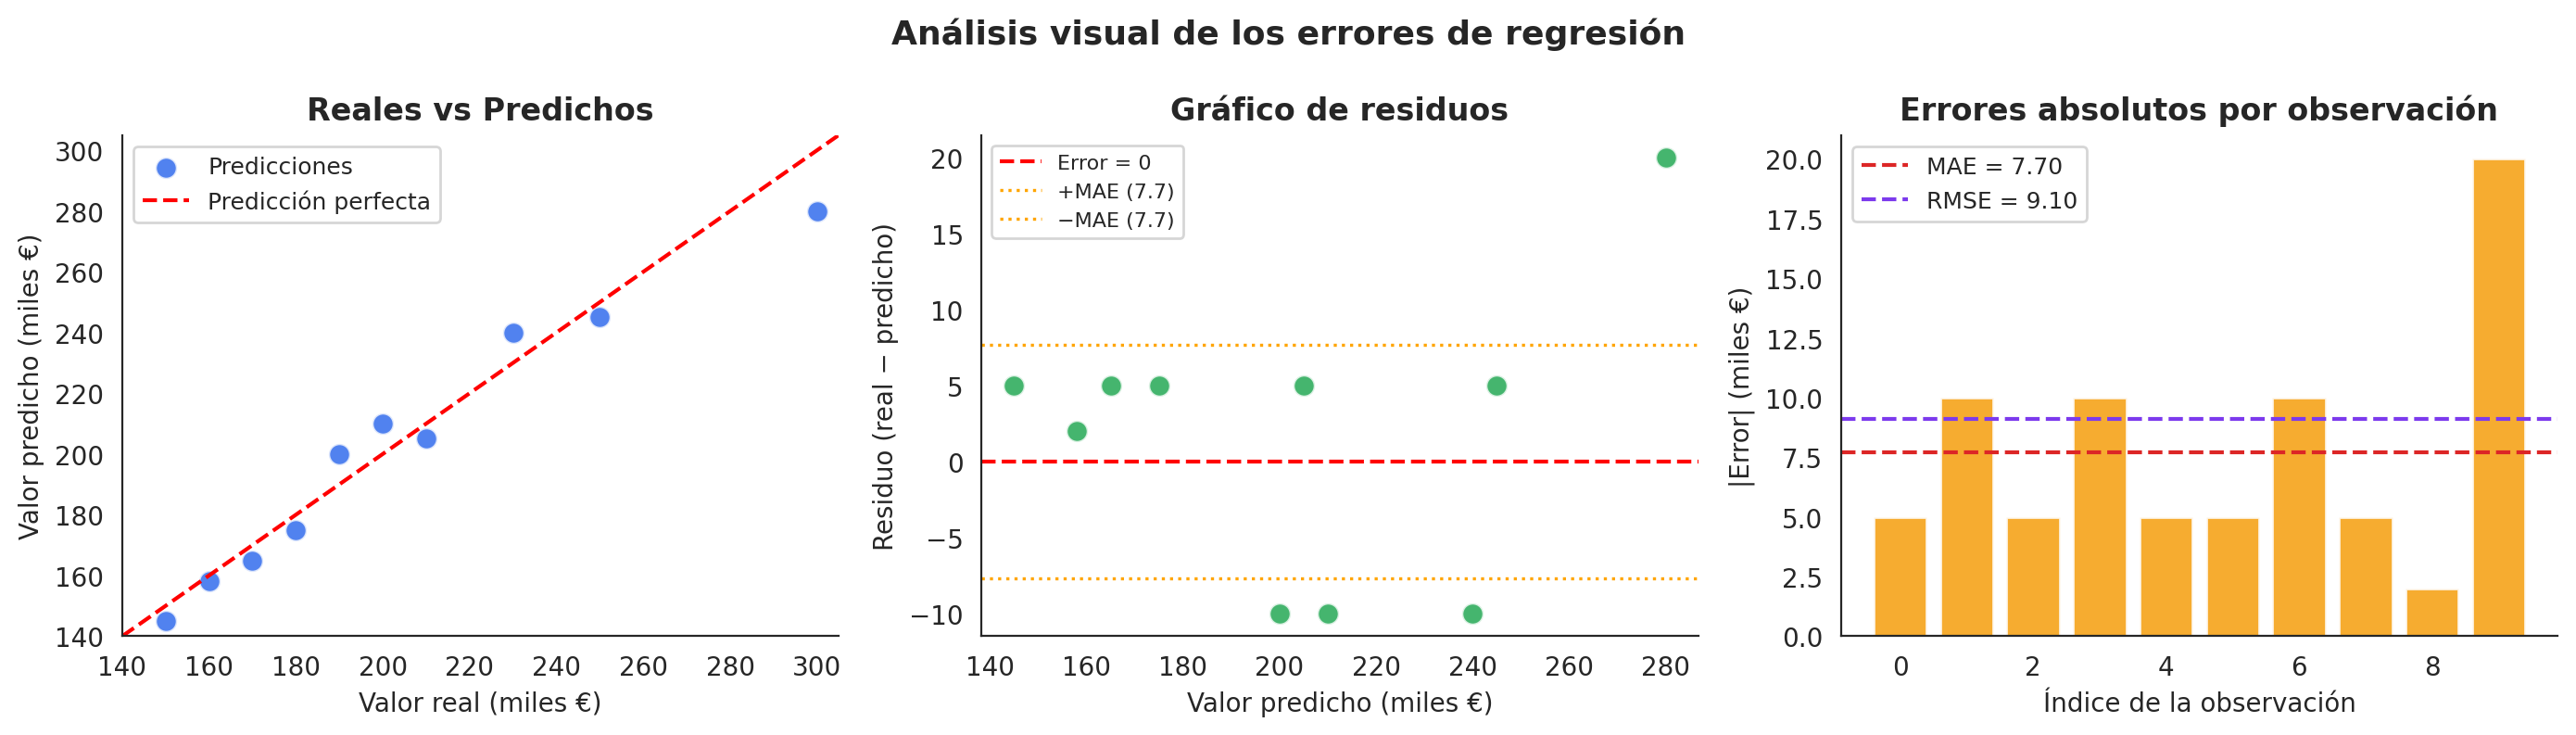

In [4]:
#@title Soluciones gráficas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Análisis visual de los errores de regresión",
             fontsize=13, fontweight='bold')

# ── Gráfico 1: Valores reales vs predichos ─────────────────────────────────────
ax = axes[0]
ax.scatter(y_real, y_pred, color='#2563eb', alpha=0.8, s=70, edgecolors='white',
           linewidth=1, label='Predicciones')
# Línea de predicción perfecta (y = ŷ)
lims = [min(y_real.min(), y_pred.min()) - 5,
        max(y_real.max(), y_pred.max()) + 5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor real (miles €)', fontsize=10)
ax.set_ylabel('Valor predicho (miles €)', fontsize=10)
ax.set_title('Reales vs Predichos', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Gráfico 2: Residuos vs valores predichos ───────────────────────────────────
ax = axes[1]
ax.scatter(y_pred, errores, color='#16a34a', alpha=0.8, s=70,
           edgecolors='white', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
ax.axhline( MAE, color='orange', linestyle=':', linewidth=1.2, label=f'+MAE ({MAE:.1f})')
ax.axhline(-MAE, color='orange', linestyle=':', linewidth=1.2, label=f'−MAE ({MAE:.1f})')
ax.set_xlabel('Valor predicho (miles €)', fontsize=10)
ax.set_ylabel('Residuo (real − predicho)', fontsize=10)
ax.set_title('Gráfico de residuos', fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Gráfico 3: Distribución de los errores absolutos ──────────────────────────
ax = axes[2]
ax.bar(range(len(errores_abs)), errores_abs, color='#f59e0b', alpha=0.85,
       edgecolor='white', linewidth=1)
ax.axhline(MAE,  color='#dc2626', linestyle='--', linewidth=1.5,
           label=f'MAE = {MAE:.2f}')
ax.axhline(RMSE, color='#7c3aed', linestyle='--', linewidth=1.5,
           label=f'RMSE = {RMSE:.2f}')
ax.set_xlabel('Índice de la observación', fontsize=10)
ax.set_ylabel('|Error| (miles €)', fontsize=10)
ax.set_title('Errores absolutos por observación', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Cómo leer los gráficos:**

- **Reales vs predichos:** los puntos deben estar lo más cerca posible de la línea roja discontinua (la línea de predicción perfecta donde $y = \hat{y}$). Un modelo perfecto tendría todos los puntos sobre esa línea.
- **Gráfico de residuos:** los residuos deben distribuirse aleatoriamente alrededor del cero, sin patrones sistemáticos. Si ves una curva o una forma de embudo, el modelo tiene problemas estructurales (no-linealidad o heterocedasticidad).
- **Errores absolutos:** permite identificar observaciones individuales donde el modelo falla más. Si hay una barra muy por encima de las demás, puede ser un valor atípico o un caso que el modelo no representa bien.


### El efecto de los valores atípicos: por qué MAE y RMSE divergen

Este experimento ilustra visualmente por qué la elección entre MAE y RMSE importa cuando hay valores atípicos en el conjunto de datos.

Comparación de métricas SIN y CON valor atípico

Sin valor atípico:
  MAE:      6.26 k€
  RMSE:     7.61 k€
  MAPE:     3.25%
  sMAPE:    3.23%
  RMSE/MAE: 1.22  (1.0 = sin atípicos; >1.3 = atípicos influyentes)

Con valor atípico:
  MAE:      9.89 k€
  RMSE:     18.66 k€
  MAPE:     5.02%
  sMAPE:    4.71%
  RMSE/MAE: 1.89  (1.0 = sin atípicos; >1.3 = atípicos influyentes)

Impacto del atípico:
  MAE aumentó   un 58.0%
  RMSE aumentó  un 145.2%
  MAPE aumentó  un 54.4%
  sMAPE aumentó un 45.7%
  → El RMSE es mucho más sensible al atípico que MAE, MAPE y sMAPE


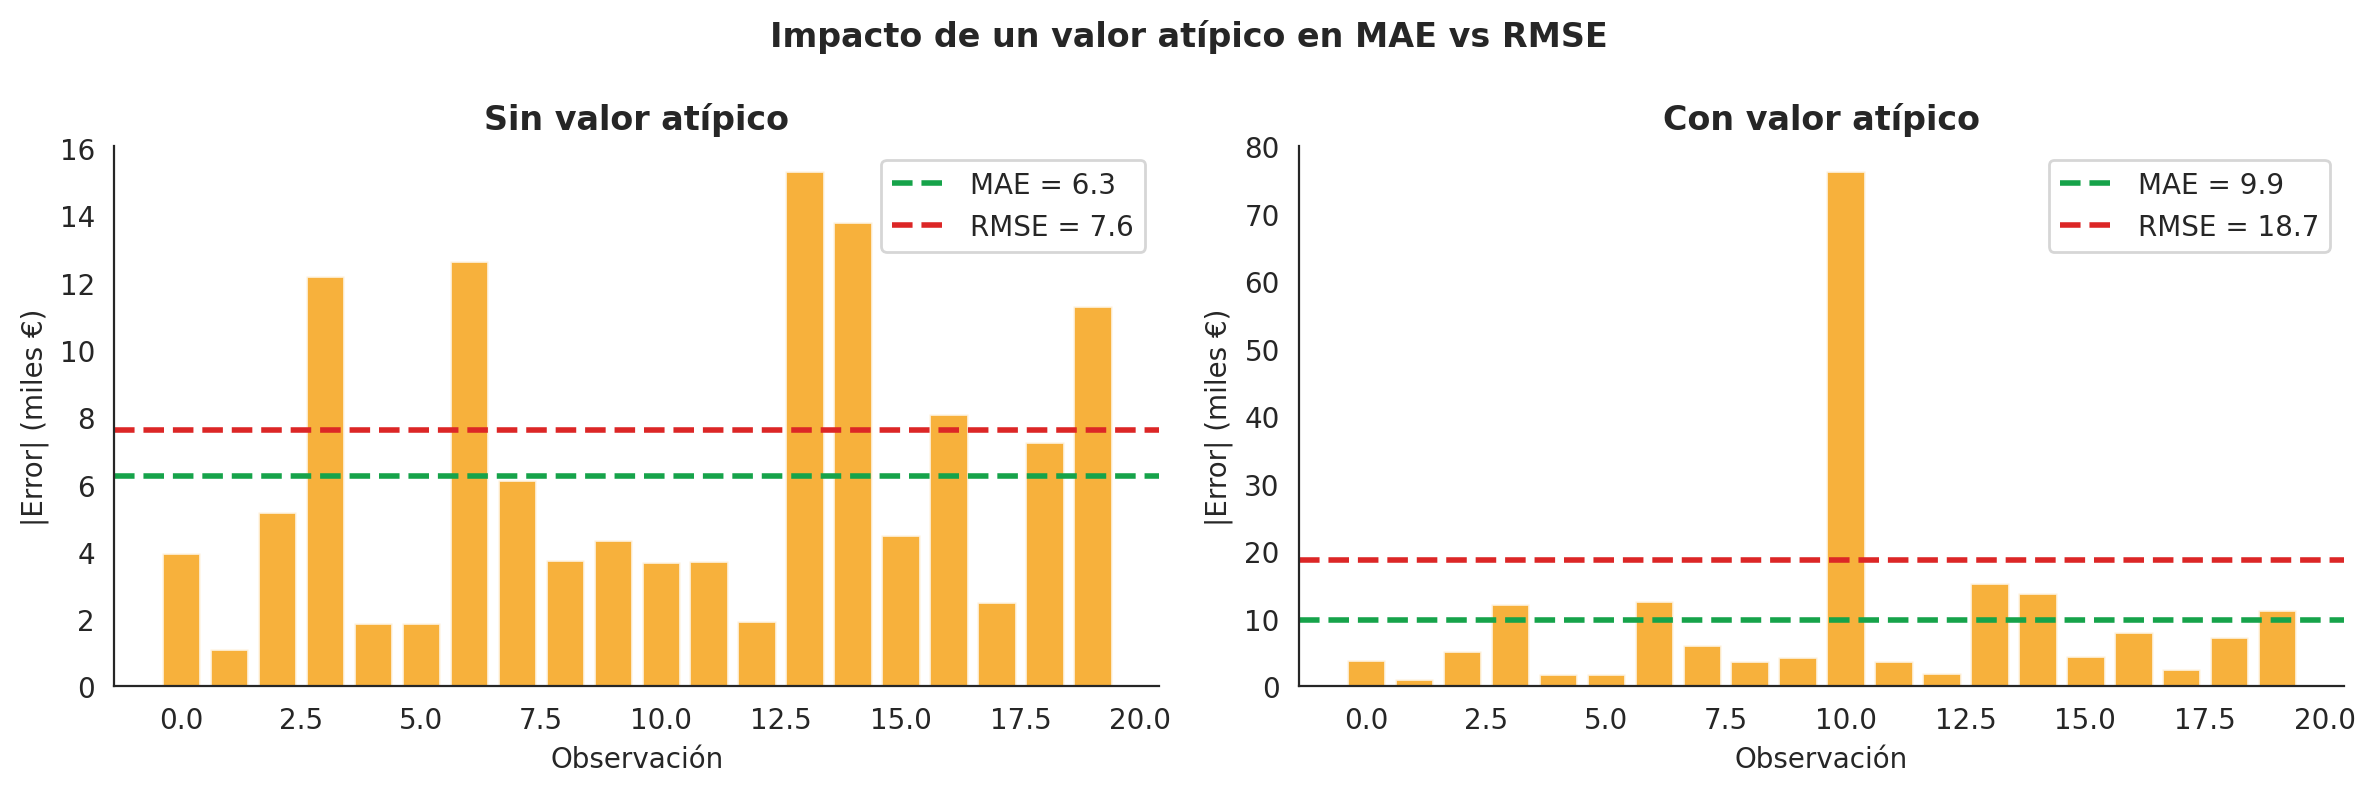


Observa que MAE apenas cambia con el atípico, mientras que RMSE sube drásticamente.


In [5]:
#@title Impacto de atípicos en las métricas
np.random.seed(42)

# Datos base: predicciones razonablemente buenas
y_base  = np.linspace(100, 300, 20)
y_pred_base = y_base + np.random.normal(0, 8, 20)

# Versión con un valor atípico: un error puntual muy grande
y_pred_atipico = y_pred_base.copy()
y_pred_atipico[10] += 80   # error de 80 k€ en la observación 10

# Calcular métricas en ambos escenarios
def calcular_metricas(y_r, y_p, nombre):
    mse   = ((y_r - y_p)**2).mean()
    rmse  = np.sqrt(mse)
    mae   = np.abs(y_r - y_p).mean()
    mape  = (np.abs(y_r - y_p) / np.abs(y_r)).mean() * 100
    denom = (np.abs(y_r) + np.abs(y_p)) / 2
    smape = (np.abs(y_r - y_p) / denom).mean() * 100
    print(f"\n{nombre}:")
    print(f"  MAE:      {mae:.2f} k€")
    print(f"  RMSE:     {rmse:.2f} k€")
    print(f"  MAPE:     {mape:.2f}%")
    print(f"  sMAPE:    {smape:.2f}%")
    print(f"  RMSE/MAE: {rmse/mae:.2f}  (1.0 = sin atípicos; >1.3 = atípicos influyentes)")
    return mae, rmse, mape, smape

print("Comparación de métricas SIN y CON valor atípico")
print("=" * 50)
mae_base,  rmse_base,  mape_base,  smape_base  = calcular_metricas(y_base, y_pred_base,   "Sin valor atípico")
mae_atip,  rmse_atip,  mape_atip,  smape_atip  = calcular_metricas(y_base, y_pred_atipico,"Con valor atípico")

print(f"\nImpacto del atípico:")
print(f"  MAE aumentó   un {(mae_atip/mae_base - 1)*100:.1f}%")
print(f"  RMSE aumentó  un {(rmse_atip/rmse_base - 1)*100:.1f}%")
print(f"  MAPE aumentó  un {(mape_atip/mape_base - 1)*100:.1f}%")
print(f"  sMAPE aumentó un {(smape_atip/smape_base - 1)*100:.1f}%")
print(f"  → El RMSE es mucho más sensible al atípico que MAE, MAPE y sMAPE")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle("Impacto de un valor atípico en MAE vs RMSE",
             fontsize=12, fontweight='bold')

for ax, y_p, titulo, mae, rmse in [
    (axes[0], y_pred_base,    "Sin valor atípico", mae_base, rmse_base),
    (axes[1], y_pred_atipico, "Con valor atípico", mae_atip, rmse_atip),
]:
    errores_abs = np.abs(y_base - y_p)
    ax.bar(range(len(errores_abs)), errores_abs, color='#f59e0b',
           alpha=0.8, edgecolor='white')
    ax.axhline(mae,  color='#16a34a', linestyle='--', linewidth=2,
               label=f'MAE = {mae:.1f}')
    ax.axhline(rmse, color='#dc2626', linestyle='--', linewidth=2,
               label=f'RMSE = {rmse:.1f}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Observación')
    ax.set_ylabel('|Error| (miles €)')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('atipicos_mae_rmse.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nObserva que MAE apenas cambia con el atípico, mientras que RMSE sube drásticamente.")

### Resumen y reglas de uso

```python
# Imprimir guía de referencia rápida
guia = """
╔══════════════════════════════════════════════════════════════════╗
║         GUÍA DE SELECCIÓN DE MÉTRICAS — REGRESIÓN               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MSE                                                             ║
║  · Útil durante el entrenamiento (diferenciable; base de        ║
║    muchos algoritmos de optimización)                            ║
║  · Interpreta difícil: unidades al cuadrado                      ║
║  · Muy sensible a errores grandes                                ║
║                                                                  ║
║  RMSE  ← métrica de referencia más usada                         ║
║  · Mismas unidades que la variable objetivo                      ║
║  · Fácil de interpretar: "el modelo se equivoca en promedio X"  ║
║  · Sensible a atípicos (amplifica errores grandes)               ║
║                                                                  ║
║  MAE                                                             ║
║  · Robusta ante valores atípicos                                 ║
║  · Mismas unidades que la variable objetivo                      ║
║  · Menos sensible a errores grandes que RMSE                     ║
║  · Preferible cuando los errores extremos no son críticos        ║
║                                                                  ║
║  MAPE  ← estándar en forecasting                                 ║
║  · Resultado en porcentaje: muy comunicable (ej. "error del 4%")║
║  · Permite comparar modelos sobre series de distinta escala      ║
║  · NO usar si algún y_real puede ser cero o muy cercano a cero  ║
║  · Penaliza más las subestimaciones que las sobreestimaciones    ║
║                                                                  ║
║  sMAPE                                                           ║
║  · Versión simétrica del MAPE: trata igual sobre y subestimación║
║  · Acotado entre 0% y 200%                                       ║
║  · Más estable cuando los valores son pequeños                   ║
║  · No en scikit-learn: implementar manualmente                   ║
║                                                                  ║
║  R²  (coeficiente de determinación)                              ║
║  · Adimensional: siempre entre -∞ y 1 (un modelo perfecto = 1) ║
║  · Permite comparar modelos sobre distintos datasets             ║
║  · Puede ser negativo si el modelo es peor que predecir          ║
║    siempre la media                                              ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  REGLAS PRÁCTICAS                                                ║
║  Si RMSE >> MAE          → hay atípicos; usar MAE o sMAPE       ║
║  Si RMSE ≈ MAE           → errores homogéneos; usar RMSE        ║
║  Si necesitas comparar   → usar MAPE o sMAPE (adimensionales)   ║
║    series de distinta escala                                     ║
║  Si y puede valer cero   → NO usar MAPE; usar sMAPE o MAE       ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(guia)
```


## Métricas para problemas de clasificación

En los problemas de clasificación el objetivo es predecir correctamente la categoría de clasificación de cada observación. Así pues, las métricas naturales para evaluar estos modelos estarán basadas en contabilizar las coincidencias entre la clasificación correcta y la conseguida o predicha con el modelo.

Para definir estos indicadores partimos de identificar las clasificaciones posibles, cuestión que salvamos con una **matriz de confusión**, esto es, una tabla que muestra el número de predicciones correctas e incorrectas realizadas por un clasificador en todas las clases disponibles. En el caso de una respuesta binaria, 0=Negativo y 1=Positivo en relación al hecho de que se dé determinada característica, las clasificaciones/predicciones posibles sobre el total de datos o registros disponibles son las que se muestran en la siguiente matriz:

|                     |       | **Valor** | **Predicho** |
|---------------------|-------|--------------------|--------------|
|                     |       |        **0**       |     **1**    |
| **Valor** | **0** |         TN         |      FP      |
| **Observado**       | **1** |         FN         |      TP      |

Se identifican pues, los siguientes números:

* **TP**, *True Positive* o Verdaderos positivos, que es el número de registros que se clasifican correctamente como positivos.

* **FP**, *False Positive* o Falsos positivos es el número de registros que siendo negativos (0), se clasifican de modo incorrecto como positivos (1).  

* **TN**, *True Negative* o Verdaderos negativos es el número de registros negativos (0) que con correctamente clasificados como negativos.

* **FN**, *False Negative* o Falsos negativos es el número de registros positivos (1) que son clasificados incorrectamente (con 0).

En base a estos números se definen las siguientes métricas de evaluación de los modelos de aprendizaje basados en clasificación:

- La **exactitud** (representado en la literatura por A, de *accuracy*) es la métrica más utilizada y muestra la capacidad del modelo para hacer predicciones correctas. Se calcula a partir de la proporción de observaciones clasificadas correctamente (TP + TN sobre el total), esto es,

$$Exactitud (A)= \frac{TP + TN}{TP + TN + FP + FN}.$$

La exactitud es un indicador de la bondad del modelo para hacer predicciones correctas, por lo que  sólo será útil cuando el conjunto de datos esté repartido de forma equilibrada entre las categorías de respuesta.

Supongamos que hemos construido un clasificador de imágenes que distingue entre caballos y humanos, con 250 imágenes de caballos y otras 250 de humanos. Si el modelo predice correctamente 400 imágenes en total (caballos y humanos), su exactitud es de 0.8, o lo que es lo mismo, del 80% en términos porcentuales.

Cuando tenemos un conjunto de datos sesgado o desequilibrado hacia alguna categoría, necesitamos una perspectiva diferente sobre cómo evaluar el modelo. Por ejemplo, si tenemos 450 imágenes de caballos y 50 imágenes de humanos, hay una probabilidad del 90% (450/500) de que el caballo se prediga correctamente porque el conjunto de datos está dominado por los caballos. Y aunque la predicción sea nefasta para los humanos, la exactitud seguirá siendo buena.

Surgen pues otras métricas que, en estas circunstancias, serán más útiles que la exactitud, como la precisión, el recuerdo y la puntuación F1.

La **precisión** (representado habitualmente como P, de *precision*) representa el porcentaje de observaciones correctamente clasificadas, de entre las que se han clasificado como positivas.

$$Precisión (P)= \frac{TP}{TP + FP}.$$

Por ejemplo, nos podría interesar especialmente saber, de las imágenes que se clasificaron como humanos, cuántas eran realmente de humanos.

Por otro lado, el **recuerdo** (representado por R, de *recall*) muestra el porcentaje de las observaciones que siendo positivas se clasificaron correctamente, y nos resulta útil cuando nos interesa especialmente la clasificación correcta de una determinada clase.

$$Recuerdo (R)= \frac{TP}{TP+FN}.$$

En el ejemplo de caballos y humanos, descubriríamos, con el recuerdo, de las imágenes que eran de humanos, qué porcentaje fueron correctamente clasificadas como humanos.

Dado que existe cierta relación entre la precisión y la recuperación, y a menudo el aumento de una conlleva la disminución de la otra, se propuso otra métrica construida a partir de las dos, para conjugar las ventajas de ambas.

La **puntuación F1** (o *F1 Score*) es la media armónica de la precisión y la recuperación, y muestra lo bueno que es el modelo a la hora de clasificar todas las clases sin tener que equilibrar la precisión y la recuperación. Si la precisión o la recuperación son muy bajas, la puntuación F1 también lo será.

$$F1 = \frac{2 \cdot P \cdot R}{P + R}.$$

### Métricas adicionales derivadas de la matriz de confusión

Además de las cuatro métricas anteriores, existen otras que conviene conocer porque aparecen frecuentemente en la literatura y aportan perspectivas complementarias sobre el comportamiento del clasificador.

La **especificidad** (o *Specificity*, también llamada *True Negative Rate*, TNR) mide la capacidad del modelo para identificar correctamente los negativos: de todos los casos que realmente son negativos, ¿qué proporción clasifica bien?

$$Especificidad = \frac{TN}{TN + FP}$$

Mientras que el recuerdo se centra en los positivos, la especificidad se centra en los negativos. Ambas métricas son complementarias: un modelo que clasifica todo como positivo tendría recuerdo = 1 pero especificidad = 0. En diagnóstico médico, por ejemplo, interesa que la especificidad sea alta para evitar alarmar a pacientes sanos.

La **tasa de falsos positivos** (*False Positive Rate*, FPR) es directamente el complemento de la especificidad y representa la proporción de negativos reales que el modelo clasifica erróneamente como positivos:

$$FPR = \frac{FP}{FP + TN} = 1 - Especificidad$$

La **tasa de falsos negativos** (*False Negative Rate*, FNR) es el complemento del recuerdo: la proporción de positivos reales que el modelo clasifica erróneamente como negativos:

$$FNR = \frac{FN}{FN + TP} = 1 - Recuerdo$$

El **valor predictivo negativo** (*Negative Predictive Value*, NPV) es el análogo de la precisión pero para la clase negativa: de todos los casos que el modelo predice como negativos, ¿qué porcentaje lo es realmente?

$$VPN = \frac{TN}{TN + FN}$$

La **puntuación F-beta** (*F-beta Score*) es una generalización del F1 que permite ajustar el peso relativo que se da a la precisión frente al recuerdo según el contexto del problema. El parámetro $\beta$ controla ese equilibrio:

$$F_\beta = \frac{(1 + \beta^2) \cdot P \cdot R}{\beta^2 \cdot P + R}$$

- Con $\beta = 1$ se recupera el F1 (precisión y recuerdo tienen el mismo peso).
- Con $\beta = 2$ (F2) el recuerdo pesa el doble que la precisión: útil cuando los falsos negativos son más costosos que los falsos positivos (p.ej. diagnóstico de enfermedades graves).
- Con $\beta = 0.5$ (F0.5) la precisión pesa el doble: útil cuando los falsos positivos son más costosos (p.ej. filtros antispam donde clasificar un correo legítimo como spam es muy perjudicial).

El **coeficiente kappa de Cohen** (*Cohen's Kappa*, $\kappa$) mide el acuerdo entre las predicciones del modelo y los valores reales, corrigiendo el acierto esperado por azar. Es especialmente útil cuando las clases están desbalanceadas, porque penaliza un modelo que acierta mayoritariamente por la distribución de las clases y no por haber aprendido:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde $p_o$ es la exactitud observada y $p_e$ es el acierto esperado por azar dado el desequilibrio de clases. Un $\kappa = 1$ indica acuerdo perfecto; $\kappa = 0$ indica que el modelo no aporta nada por encima del azar; $\kappa < 0$ indica que el modelo es peor que el azar.

El **índice de Jaccard** (*Jaccard Index* o *Intersection over Union*, IoU) mide la similitud entre el conjunto de predicciones positivas y el conjunto de positivos reales. Se usa en segmentación de imágenes y en clasificación binaria cuando interesa cuánto se solapan ambos conjuntos:

$$Jaccard = \frac{TP}{TP + FP + FN}$$

### Métricas basadas en probabilidades: AUC-ROC y AUC-PR

Las métricas anteriores se calculan a partir de las predicciones de clase (0 ó 1) y dependen del umbral de decisión elegido (habitualmente 0.5). Sin embargo, la mayoría de los clasificadores producen una **probabilidad** de pertenecer a la clase positiva. Las métricas basadas en probabilidades evalúan el clasificador para todos los posibles umbrales simultáneamente.

#### Curva ROC y AUC-ROC

La **curva ROC** (*Receiver Operating Characteristic*) representa gráficamente el comportamiento del clasificador a lo largo de todos los posibles umbrales de decisión. Para cada umbral, se calcula la tasa de verdaderos positivos (TPR = Recuerdo) frente a la tasa de falsos positivos (FPR), y se representa el punto resultante en un gráfico:

- Eje Y: TPR = $\frac{TP}{TP + FN}$ (Recuerdo / Sensibilidad)
- Eje X: FPR = $\frac{FP}{FP + TN}$ (1 − Especificidad)

Un clasificador perfecto tiene la curva ROC en la esquina superior izquierda (TPR = 1, FPR = 0). Un clasificador aleatorio produce una línea diagonal de pendiente 1.

El **área bajo la curva ROC** (AUC-ROC, *Area Under the ROC Curve*) resume toda la curva en un único número entre 0 y 1:

- AUC = 1.0 → clasificador perfecto
- AUC = 0.5 → clasificador aleatorio (inútil)
- AUC < 0.5 → el modelo es peor que el azar (las predicciones están invertidas)

La interpretación probabilística del AUC-ROC es especialmente útil: un AUC = 0.85 significa que si tomamos al azar un caso positivo y un caso negativo, el modelo asigna mayor probabilidad al positivo en el 85% de las veces.

#### Curva Precisión-Recuerdo y AUC-PR

Cuando el conjunto de datos está muy desbalanceado (por ejemplo, detección de fraude donde los casos positivos son el 1% del total), la curva ROC puede dar una imagen demasiado optimista del rendimiento real. En estos casos, la **curva Precisión-Recuerdo** (PR) es más informativa.

La curva PR representa, para cada umbral:
- Eje Y: Precisión = $\frac{TP}{TP + FP}$
- Eje X: Recuerdo = $\frac{TP}{TP + FN}$

El **área bajo la curva PR** (AUC-PR o Average Precision, AP) también se resume en un número entre 0 y 1. Un clasificador aleatorio en un dataset con proporción $\pi$ de positivos tendrá AUC-PR ≈ $\pi$. Por eso, en datasets muy desbalanceados (π muy pequeño), incluso un AUC-PR moderado puede representar un clasificador muy bueno.

> **Regla práctica:** cuando las clases están equilibradas, usa AUC-ROC. Cuando hay desbalance fuerte (ratio > 1:10), usa AUC-PR como métrica principal.

### Tabla resumen de métricas de clasificación

| Métrica | Fórmula | Rango | Cuándo es especialmente útil |
|---|---|---|---|
| **Exactitud (A)** | $\frac{TP+TN}{TP+TN+FP+FN}$ | [0, 1] | Clases equilibradas |
| **Precisión (P)** | $\frac{TP}{TP+FP}$ | [0, 1] | Minimizar falsos positivos costosos |
| **Recuerdo (R)** | $\frac{TP}{TP+FN}$ | [0, 1] | Minimizar falsos negativos costosos |
| **Especificidad** | $\frac{TN}{TN+FP}$ | [0, 1] | Diagnóstico médico; no alarmar a sanos |
| **F1** | $\frac{2PR}{P+R}$ | [0, 1] | Balance precisión-recuerdo; clases desbalanceadas |
| **F-beta** | $\frac{(1+\beta^2)PR}{\beta^2 P+R}$ | [0, 1] | Cuando un error es más costoso que el otro |
| **VPN** | $\frac{TN}{TN+FN}$ | [0, 1] | Cuando importa la fiabilidad de los negativos |
| **FPR** | $\frac{FP}{FP+TN}$ | [0, 1] | Eje X de la curva ROC |
| **FNR** | $\frac{FN}{FN+TP}$ | [0, 1] | Sistemas de seguridad; alertas críticas |
| **Kappa de Cohen** | $\frac{p_o - p_e}{1-p_e}$ | [-1, 1] | Clases desbalanceadas; corrección por azar |
| **Jaccard** | $\frac{TP}{TP+FP+FN}$ | [0, 1] | Segmentación de imágenes; IoU |
| **AUC-ROC** | Área bajo curva ROC | [0, 1] | Comparar modelos; clases equilibradas |
| **AUC-PR** | Área bajo curva PR | [0, 1] | Clases muy desbalanceadas |

### Implementación desde cero en Python


In [6]:
#@title ── Datos de ejemplo ───
# Etiquetas reales y predicciones binarias de un clasificador hipotético
y_real = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
                   1, 1, 0, 0, 1, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
                   1, 0, 0, 1, 1, 0, 0, 0, 1, 1])

# ── Calcular componentes de la matriz de confusión ────────────────────────────
TP = int(((y_real == 1) & (y_pred == 1)).sum())
TN = int(((y_real == 0) & (y_pred == 0)).sum())
FP = int(((y_real == 0) & (y_pred == 1)).sum())
FN = int(((y_real == 1) & (y_pred == 0)).sum())
N  = TP + TN + FP + FN   # total de observaciones

print("Matriz de confusión:")
print(f"                Predicho 0  Predicho 1")
print(f"  Real 0   TN={TN:3d}       FP={FP:3d}")
print(f"  Real 1   FN={FN:3d}       TP={TP:3d}")
print()

# ── Calcular todas las métricas manualmente ───────────────────────────────────
exactitud    = (TP + TN) / N
precision    = TP / (TP + FP) if (TP + FP) > 0 else 0
recuerdo     = TP / (TP + FN) if (TP + FN) > 0 else 0
especif      = TN / (TN + FP) if (TN + FP) > 0 else 0
vpn          = TN / (TN + FN) if (TN + FN) > 0 else 0
fpr          = FP / (FP + TN) if (FP + TN) > 0 else 0
fnr          = FN / (FN + TP) if (FN + TP) > 0 else 0
f1           = 2 * precision * recuerdo / (precision + recuerdo) if (precision + recuerdo) > 0 else 0

# F-beta con beta=2 (recuerdo pesa el doble)
beta = 2
f_beta = (1 + beta**2) * precision * recuerdo / (beta**2 * precision + recuerdo) \
         if (beta**2 * precision + recuerdo) > 0 else 0

# Kappa de Cohen
p_e = ((TP + FP) / N) * ((TP + FN) / N) + \
      ((TN + FN) / N) * ((TN + FP) / N)
kappa = (exactitud - p_e) / (1 - p_e) if (1 - p_e) > 0 else 0

# Jaccard
jaccard = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0

print("=" * 50)
print("  MÉTRICAS DE CLASIFICACIÓN — cálculo manual")
print("=" * 50)
print(f"  Exactitud (A):     {exactitud:.4f}")
print(f"  Precisión (P):     {precision:.4f}")
print(f"  Recuerdo (R):      {recuerdo:.4f}")
print(f"  Especificidad:     {especif:.4f}")
print(f"  VPN:               {vpn:.4f}")
print(f"  FPR:               {fpr:.4f}")
print(f"  FNR:               {fnr:.4f}")
print(f"  F1:                {f1:.4f}")
print(f"  F-beta (β={beta}):    {f_beta:.4f}")
print(f"  Kappa de Cohen:    {kappa:.4f}")
print(f"  Jaccard:           {jaccard:.4f}")
print("=" * 50)

Matriz de confusión:
                Predicho 0  Predicho 1
  Real 0   TN=  7       FP=  3
  Real 1   FN=  3       TP=  7

  MÉTRICAS DE CLASIFICACIÓN — cálculo manual
  Exactitud (A):     0.7000
  Precisión (P):     0.7000
  Recuerdo (R):      0.7000
  Especificidad:     0.7000
  VPN:               0.7000
  FPR:               0.3000
  FNR:               0.3000
  F1:                0.7000
  F-beta (β=2):    0.7000
  Kappa de Cohen:    0.4000
  Jaccard:           0.5385


In [7]:
#@title -- Verificación con scikit-learn --
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, cohen_kappa_score,
    jaccard_score, confusion_matrix, classification_report
)

exactitud_sk  = accuracy_score(y_real, y_pred)
precision_sk  = precision_score(y_real, y_pred)
recuerdo_sk   = recall_score(y_real, y_pred)
f1_sk         = f1_score(y_real, y_pred)
fbeta_sk      = fbeta_score(y_real, y_pred, beta=2)
kappa_sk      = cohen_kappa_score(y_real, y_pred)
jaccard_sk    = jaccard_score(y_real, y_pred)

print("Verificación con scikit-learn:")
print(f"  Exactitud:      {exactitud_sk:.4f}  ← manual: {np.isclose(exactitud, exactitud_sk)}")
print(f"  Precisión:      {precision_sk:.4f}  ← manual: {np.isclose(precision, precision_sk)}")
print(f"  Recuerdo:       {recuerdo_sk:.4f}  ← manual: {np.isclose(recuerdo, recuerdo_sk)}")
print(f"  F1:             {f1_sk:.4f}  ← manual: {np.isclose(f1, f1_sk)}")
print(f"  F-beta (β=2):   {fbeta_sk:.4f}  ← manual: {np.isclose(f_beta, fbeta_sk)}")
print(f"  Kappa de Cohen: {kappa_sk:.4f}  ← manual: {np.isclose(kappa, kappa_sk)}")
print(f"  Jaccard:        {jaccard_sk:.4f}  ← manual: {np.isclose(jaccard, jaccard_sk)}")
print()

# Reporte completo por clase
print("Reporte de clasificación completo:")
print(classification_report(y_real, y_pred, target_names=['Negativo', 'Positivo']))

Verificación con scikit-learn:
  Exactitud:      0.7000  ← manual: True
  Precisión:      0.7000  ← manual: True
  Recuerdo:       0.7000  ← manual: True
  F1:             0.7000  ← manual: True
  F-beta (β=2):   0.7000  ← manual: True
  Kappa de Cohen: 0.4000  ← manual: True
  Jaccard:        0.5385  ← manual: True

Reporte de clasificación completo:
              precision    recall  f1-score   support

    Negativo       0.70      0.70      0.70        10
    Positivo       0.70      0.70      0.70        10

    accuracy                           0.70        20
   macro avg       0.70      0.70      0.70        20
weighted avg       0.70      0.70      0.70        20



### Visualización de la matriz de confusión

La representación gráfica de la matriz de confusión es la forma más directa de diagnosticar dónde falla el clasificador.

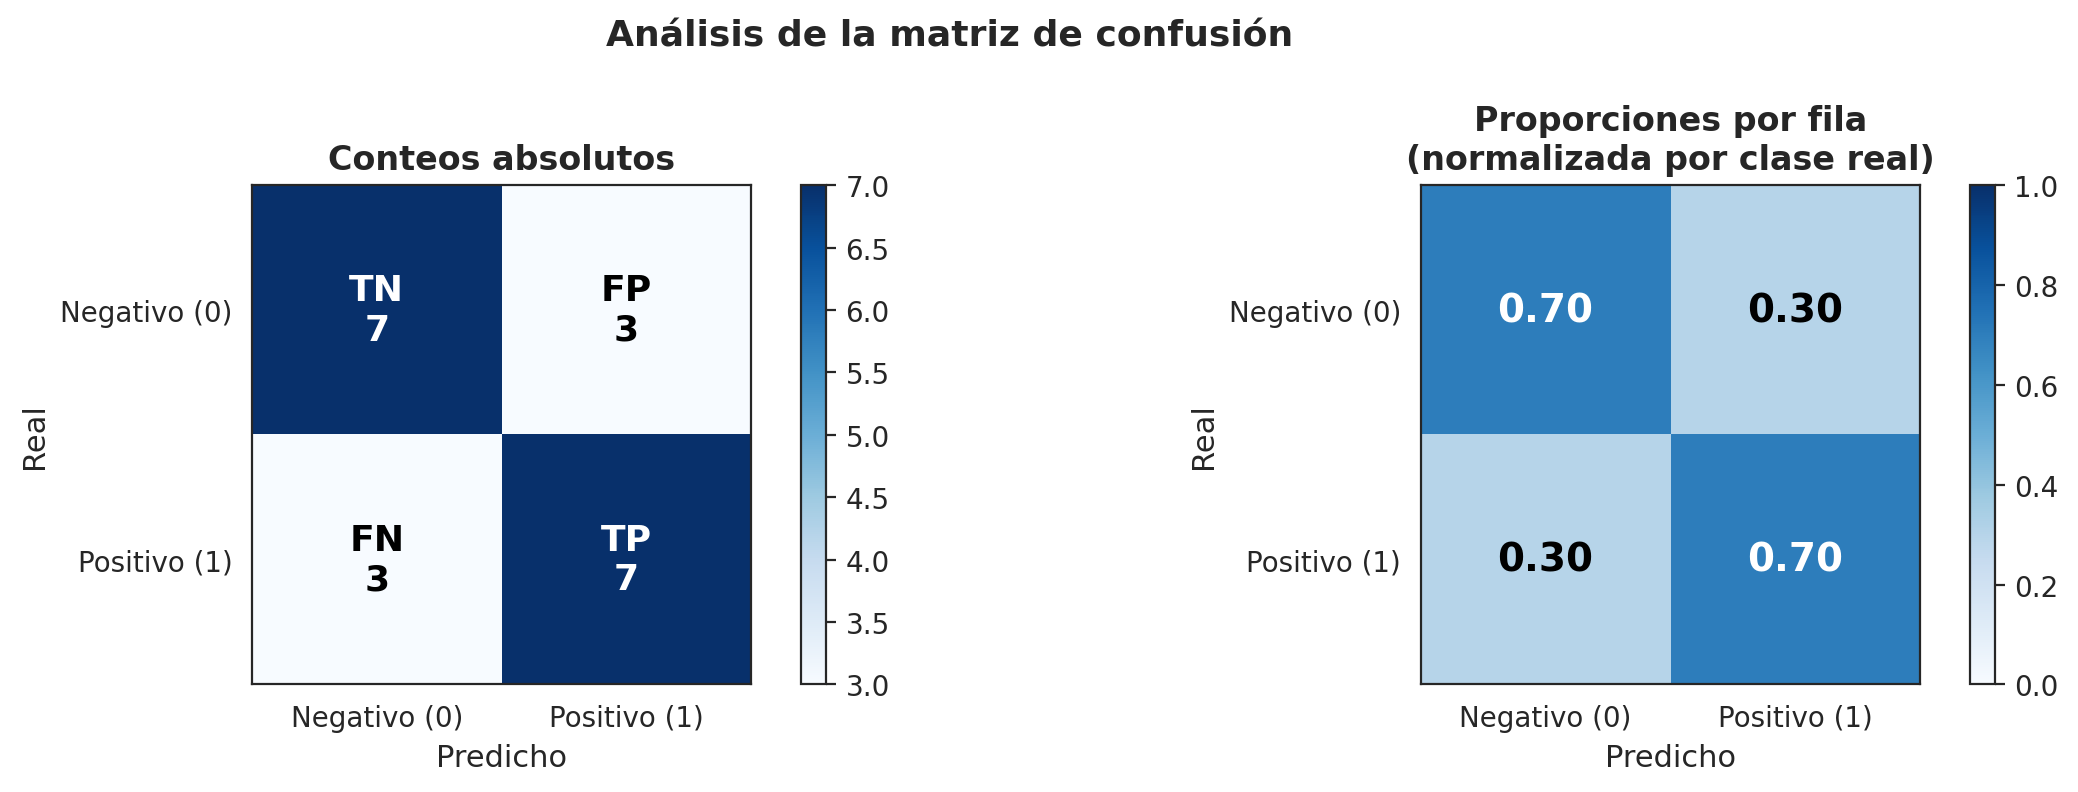

Gráfico guardado: matriz_confusion.png


In [8]:
#@title --- Matriz de confusión ---
cm = confusion_matrix(y_real, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Análisis de la matriz de confusión", fontsize=13, fontweight='bold')

# ── Panel izquierdo: matriz con conteos ────────────────────────────────────────
ax = axes[0]
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
clases = ['Negativo (0)', 'Positivo (1)']
ax.set_xticks([0, 1]); ax.set_xticklabels(clases, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(clases, fontsize=10)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Conteos absolutos', fontweight='bold')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        etiqueta = ['TN', 'FP', 'FN', 'TP'][(i * 2) + j]
        ax.text(j, i, f'{etiqueta}\n{cm[i, j]}',
                ha='center', va='center', color=color,
                fontsize=13, fontweight='bold')

# ── Panel derecho: matriz normalizada (proporciones) ──────────────────────────
ax = axes[1]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im2 = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(clases, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(clases, fontsize=10)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Proporciones por fila\n(normalizada por clase real)', fontweight='bold')
for i in range(2):
    for j in range(2):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i, j]:.2f}',
                ha='center', va='center', color=color, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado: matriz_confusion.png")

### Curva ROC y AUC-ROC

Para calcular la curva ROC necesitamos las **probabilidades** predichas por el modelo, no solo las clases. Aquí usamos un dataset real para ilustrar el proceso completo.

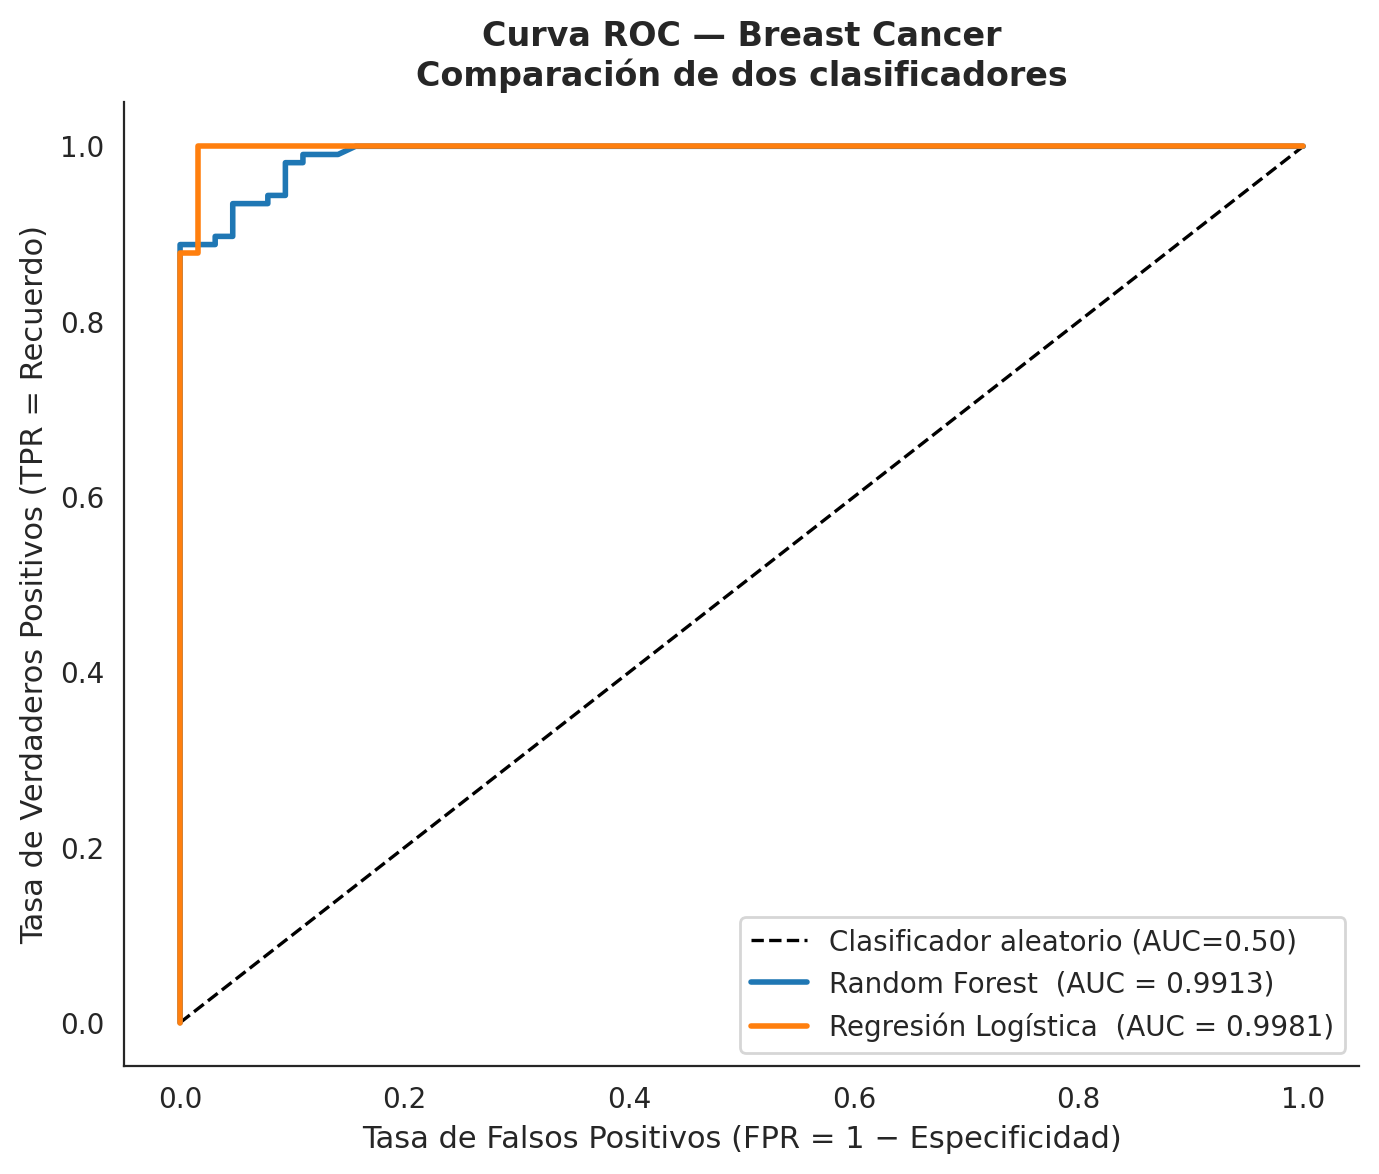

Gráfico guardado: curva_roc.png


In [9]:
#@title --- Curva ROC ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Preparar datos ─────────────────────────────────────────────────────────────
bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target   # 0 = maligno, 1 = benigno

X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.3,
                                            random_state=42, stratify=y_bc)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# ── Entrenar dos modelos para comparar sus curvas ROC ─────────────────────────
modelos = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Clasificador aleatorio (AUC=0.50)')

for nombre, modelo in modelos.items():
    modelo.fit(X_tr_s, y_tr)
    y_proba = modelo.predict_proba(X_te_s)[:, 1]
    fpr_c, tpr_c, umbrales = roc_curve(y_te, y_proba)
    auc_val = auc(fpr_c, tpr_c)
    ax.plot(fpr_c, tpr_c, linewidth=2,
            label=f'{nombre}  (AUC = {auc_val:.4f})')

ax.set_xlabel('Tasa de Falsos Positivos (FPR = 1 − Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR = Recuerdo)', fontsize=11)
ax.set_title('Curva ROC — Breast Cancer\nComparación de dos clasificadores',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado: curva_roc.png")

**Cómo leer la curva ROC:**

- Cuanto más se acerque la curva a la esquina superior izquierda, mejor clasifica el modelo.
- La **línea diagonal discontinua** representa un clasificador aleatorio (AUC = 0.5): no aporta ningún valor.
- Cada punto de la curva corresponde a un umbral de decisión diferente. Desplazarse hacia la derecha baja el umbral (clasifica más como positivo: sube TPR pero también FPR).

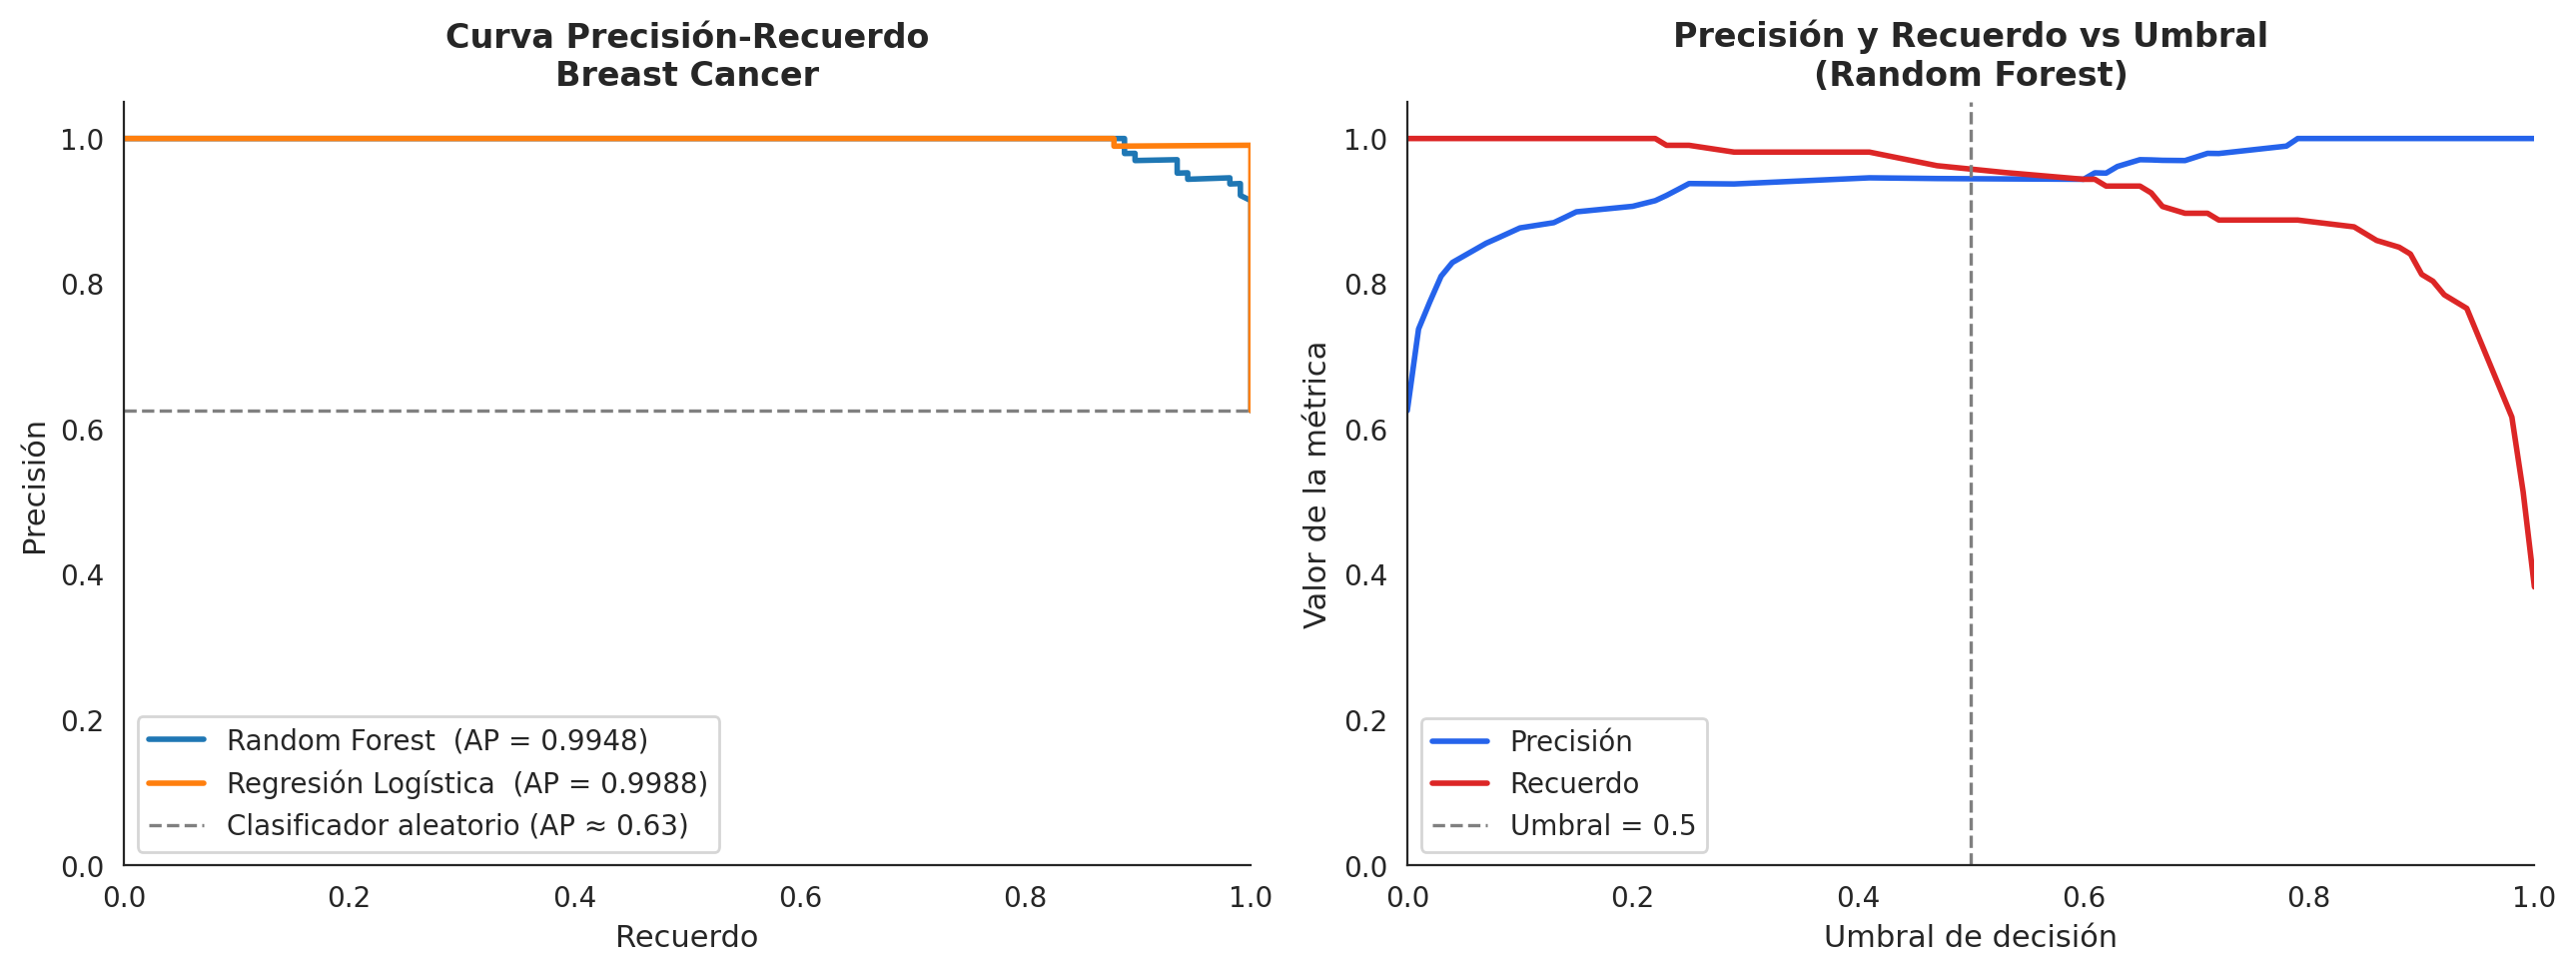

Gráfico guardado: curva_pr.png


In [10]:
#@title --- Curva Precisión-Recuerdo y AUC-PR ---
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: curva PR ─────────────────────────────────────────────────
ax = axes[0]
for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_te_s)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_te, y_proba)
    ap = average_precision_score(y_te, y_proba)
    ax.plot(rec_c, prec_c, linewidth=2,
            label=f'{nombre}  (AP = {ap:.4f})')

# Línea de referencia: clasificador aleatorio (proporción de positivos)
baseline = y_te.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
           label=f'Clasificador aleatorio (AP ≈ {baseline:.2f})')

ax.set_xlabel('Recuerdo', fontsize=11)
ax.set_ylabel('Precisión', fontsize=11)
ax.set_title('Curva Precisión-Recuerdo\nBreast Cancer', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Panel derecho: impacto del umbral en precisión y recuerdo ─────────────────
ax = axes[1]
rf = modelos['Random Forest']
y_proba_rf = rf.predict_proba(X_te_s)[:, 1]
prec_c, rec_c, thresh = precision_recall_curve(y_te, y_proba_rf)

ax.plot(thresh, prec_c[:-1], color='#2563eb', linewidth=2, label='Precisión')
ax.plot(thresh, rec_c[:-1],  color='#dc2626', linewidth=2, label='Recuerdo')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Umbral = 0.5')
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Precisión y Recuerdo vs Umbral\n(Random Forest)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('curva_pr.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado: curva_pr.png")

**El gráfico de la derecha** ilustra el **trade-off precisión-recuerdo**: al subir el umbral de decisión, el modelo se vuelve más exigente para clasificar como positivo, lo que aumenta la precisión pero reduce el recuerdo, y viceversa. No existe un umbral universalmente óptimo: la elección depende de los costes relativos de los falsos positivos y los falsos negativos en el contexto del problema.

### El problema del desbalance: por qué la exactitud engaña

Este experimento reproduce el ejemplo intuitivo mencionado al inicio de la sección y demuestra numéricamente por qué la exactitud es una métrica peligrosa en datasets desbalanceados.

In [11]:
#@title --- Problema de desbalance ---
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              cohen_kappa_score, average_precision_score)

np.random.seed(42)

def evaluar_clasificador(y_r, y_p, y_proba, nombre):
    """Calcula y muestra todas las métricas para un escenario dado."""
    tp = int(((y_r==1)&(y_p==1)).sum())
    tn = int(((y_r==0)&(y_p==0)).sum())
    fp = int(((y_r==0)&(y_p==1)).sum())
    fn = int(((y_r==1)&(y_p==0)).sum())
    acc   = accuracy_score(y_r, y_p)
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1    = f1_score(y_r, y_p, zero_division=0)
    kappa = cohen_kappa_score(y_r, y_p)
    auc   = roc_auc_score(y_r, y_proba)
    ap    = average_precision_score(y_r, y_proba)
    print(f"\n{'─'*55}")
    print(f"  {nombre}")
    print(f"{'─'*55}")
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print(f"  Exactitud:      {acc:.4f}  {'⚠️  engañosa' if acc > 0.85 and rec < 0.3 else ''}")
    print(f"  Precisión:      {prec:.4f}")
    print(f"  Recuerdo:       {rec:.4f}")
    print(f"  F1:             {f1:.4f}")
    print(f"  Kappa:          {kappa:.4f}")
    print(f"  AUC-ROC:        {auc:.4f}")
    print(f"  AUC-PR (AP):    {ap:.4f}")

# ── Escenario A: clases equilibradas ──────────────────────────────────────────
n = 1000
y_eq = np.concatenate([np.zeros(500), np.ones(500)])
proba_eq = np.concatenate([np.random.beta(2, 5, 500),
                            np.random.beta(5, 2, 500)])
y_pred_eq = (proba_eq >= 0.5).astype(int)

# ── Escenario B: dataset desbalanceado 90/10 ──────────────────────────────────
y_des = np.concatenate([np.zeros(900), np.ones(100)])
proba_des = np.concatenate([np.random.beta(2, 5, 900),
                             np.random.beta(5, 2, 100)])
y_pred_des = (proba_des >= 0.5).astype(int)

# ── Escenario C: modelo trivial (predice siempre negativo) ────────────────────
y_trivial  = np.zeros(1000, dtype=int)
proba_trivial = np.zeros(1000)

print("=" * 55)
print("  COMPARATIVA: CLASES EQUILIBRADAS vs DESBALANCEADAS")
print("=" * 55)
evaluar_clasificador(y_eq,  y_pred_eq,  proba_eq,  "A) Equilibrado (50/50)")
evaluar_clasificador(y_des, y_pred_des, proba_des, "B) Desbalanceado (90/10)")
evaluar_clasificador(y_des, y_trivial,  proba_trivial,
                     "C) Modelo trivial (predice siempre 0) sobre B")

print("\n💡 Observa que en el escenario C:")
print("   · Exactitud = 0.90 (parece bueno)")
print("   · Recuerdo  = 0.00 (no detecta ningún positivo)")
print("   · F1        = 0.00 (métrica honesta)")
print("   · Kappa     = 0.00 (no aporta nada sobre el azar)")

  COMPARATIVA: CLASES EQUILIBRADAS vs DESBALANCEADAS

───────────────────────────────────────────────────────
  A) Equilibrado (50/50)
───────────────────────────────────────────────────────
  TP=449  TN=446  FP=54  FN=51
  Exactitud:      0.8950  
  Precisión:      0.8926
  Recuerdo:       0.8980
  F1:             0.8953
  Kappa:          0.7900
  AUC-ROC:        0.9673
  AUC-PR (AP):    0.9695

───────────────────────────────────────────────────────
  B) Desbalanceado (90/10)
───────────────────────────────────────────────────────
  TP=91  TN=780  FP=120  FN=9
  Exactitud:      0.8710  
  Precisión:      0.4313
  Recuerdo:       0.9100
  F1:             0.5852
  Kappa:          0.5201
  AUC-ROC:        0.9539
  AUC-PR (AP):    0.8151

───────────────────────────────────────────────────────
  C) Modelo trivial (predice siempre 0) sobre B
───────────────────────────────────────────────────────
  TP=0  TN=900  FP=0  FN=100
  Exactitud:      0.9000  ⚠️  engañosa
  Precisión:      0.0000


### Métricas en clasificación multiclase

Hasta ahora hemos trabajado con clasificación binaria. Cuando hay más de dos clases, las métricas de precisión, recuerdo y F1 se generalizan mediante tres estrategias de promediado:

- **Macro:** calcula la métrica para cada clase por separado y promedia, dando el mismo peso a todas las clases independientemente de su frecuencia. Útil cuando todas las clases son igualmente importantes.
- **Weighted:** calcula la métrica para cada clase y promedia ponderando por el número de muestras de cada clase. Refleja el rendimiento general del modelo.
- **Micro:** agrega los TP, FP y FN de todas las clases antes de calcular la métrica. En clasificación multiclase, micro-F1 = exactitud.

Reporte completo — Iris (3 clases):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45


F1 según estrategia de promediado:
  F1 macro     : 0.8878
  F1 weighted  : 0.8878
  F1 micro     : 0.8889


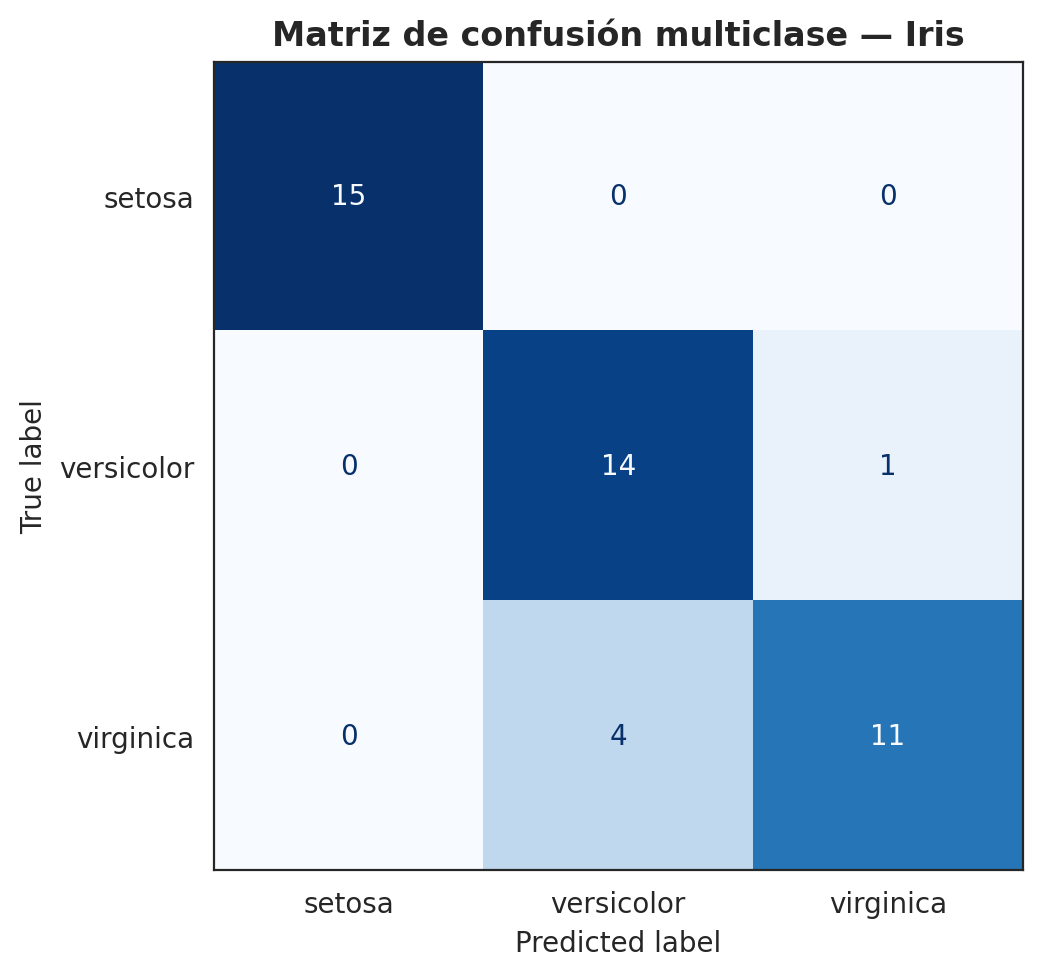

Gráfico guardado: confusion_multiclase.png


In [12]:
#@title --- Métricas multiclase ---
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

iris = load_iris()
X_ir, X_te_ir, y_ir, y_te_ir = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target)

rf_ir = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ir.fit(X_ir, y_ir)
y_pred_ir = rf_ir.predict(X_te_ir)

print("Reporte completo — Iris (3 clases):")
print(classification_report(y_te_ir, y_pred_ir,
                              target_names=iris.target_names))

print("\nF1 según estrategia de promediado:")
for avg in ['macro', 'weighted', 'micro']:
    print(f"  F1 {avg:10s}: {f1_score(y_te_ir, y_pred_ir, average=avg):.4f}")

# Visualizar la matriz de confusión multiclase
fig, ax = plt.subplots(figsize=(6, 5))
cm_ir = confusion_matrix(y_te_ir, y_pred_ir)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ir,
                               display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión multiclase — Iris', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_multiclase.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gráfico guardado: confusion_multiclase.png")

### Elegir la métrica correcta según el contexto

La elección de la métrica de evaluación no es una decisión técnica, sino una decisión de negocio. La pregunta clave es: **¿cuál es el coste relativo de equivocarse en una dirección frente a la otra?**

```
¿Las clases están equilibradas?
│
├── SÍ → Exactitud es una buena métrica de referencia
│         Complementar con AUC-ROC para comparar modelos
│
└── NO (desbalance) → NO usar exactitud como métrica principal
          │
          ├── ¿Los falsos negativos son más costosos?
          │   (p.ej. diagnóstico de enfermedad, detección de fraude)
          │   └── Priorizar RECUERDO y F2 · AUC-PR
          │
          ├── ¿Los falsos positivos son más costosos?
          │   (p.ej. spam, alertas de seguridad con muchas alarmas)
          │   └── Priorizar PRECISIÓN y F0.5
          │
          └── ¿Ambos errores son igual de costosos?
              └── F1 · Kappa de Cohen · AUC-ROC
```

In [13]:
#@title --- Resumen rápido ejecutable ---
contextos = [
    ("Diagnóstico médico (cáncer)",        "Recuerdo + F2",       "Minimizar FN: no perder enfermos"),
    ("Filtro antispam",                    "Precisión + F0.5",    "Minimizar FP: no bloquear emails legítimos"),
    ("Detección de fraude bancario",       "AUC-PR + F1",         "Desbalance extremo + ambos errores costosos"),
    ("Reconocimiento de imágenes (Iris)",  "Exactitud + F1 macro","Clases equilibradas + todas igual de importantes"),
    ("Predicción de abandono de clientes", "Recuerdo + AUC-ROC",  "Interesa recuperar todos los que se irán"),
    ("Clasificación de riesgo crediticio", "Kappa + AUC-ROC",     "Desbalance moderado + corrección por azar"),
]

print("=" * 75)
print(f"  {'Contexto':<38} {'Métrica principal':<22} {'Razón'}")
print("=" * 75)
for contexto, metrica, razon in contextos:
    print(f"  {contexto:<38} {metrica:<22} {razon}")

  Contexto                               Métrica principal      Razón
  Diagnóstico médico (cáncer)            Recuerdo + F2          Minimizar FN: no perder enfermos
  Filtro antispam                        Precisión + F0.5       Minimizar FP: no bloquear emails legítimos
  Detección de fraude bancario           AUC-PR + F1            Desbalance extremo + ambos errores costosos
  Reconocimiento de imágenes (Iris)      Exactitud + F1 macro   Clases equilibradas + todas igual de importantes
  Predicción de abandono de clientes     Recuerdo + AUC-ROC     Interesa recuperar todos los que se irán
  Clasificación de riesgo crediticio     Kappa + AUC-ROC        Desbalance moderado + corrección por azar


# <font color="steelblue">7. Retos de los sistemas de aprendizaje automático</font>

Al igual que cualquier otra tecnología, el aprendizaje automático ofrece desafíos, relacionados tanto con la mejora de los datos como con la mejora de los modelos de ajuste.

No puede haber buenos modelos con malos datos, pero es un hecho que en el mundo real es raro encontrar "buenos datos" a la primera. Por lo general los datos presentan desorden, errores, incoherencias, y se convierte en todo un arte la labor de procesarlos (depurar, etiquetar, e incluso crear nuevas variables) para conseguir una base de datos apta para iniciar el ajuste de un modelo.

Por otro lado, una vez disponemos de una base de datos razonablemente buena, el ajuste del modelo no es una labor trivial. En principio se inicia la labor de elegir qué modelo o modelos son razonables para los objetivos y el tipo de datos. A continuación hay que ajustarlos y compararlos para tomar una decisión.

Cuando ajustamos un modelo lo haremos sobre una submuestra del banco de datos, la muestra de entrenamiento, que si no está bien seleccionada y contiene todas las características de la población que representa, ocasionará sesgos. Otra parte de la muestra se dedica a la validación, es decir, a evaluar el error que genera el modelo ajustado en la predicción, y utilizarlo para volver sobre el ajuste y afinarlo en pos de reducir el error de predicción y asegurar la estabilidad de la predicción. Se puede optar también por utilizar otra parte de la muestra para la evaluación o testado del modelo que se ha ajustado. En la bibliografía encontramos diferentes recomendaciones sobre el porcentaje de la muestra que ha de dedicarse a cada parte. Una opción puede ser 70/20/10, pero es el científico de datos el que decide, en función de utilizar el mayor número de datos para entrenar el modelo (y conseguir así una buena representación de las características de la población a ajustar), y también en función de no sobrecargar el aprendizaje con los cálculos del error de validación. La muestra final de testado podría tener una representación mayor si el objetivo es concluir sobre la bondad de un modelo en la predicción de datos que no ha visto antes, esto es, que no ha utilizado para entrenar o validar.

Ya en el ajuste se nos pueden presentar dos tipos de problemas: el infra-ajuste (*underfitting*) y el sobre-ajuste (*overfitting*). Veamos en qué consisten.

El **infra-ajuste** o infra-adaptación del modelo se produce cuando el modelo da malos resultados (en términos de métricas de error) con los datos de entrenamiento (por ejemplo, una clasificación correcta de sólo el 50% de la muestra). Un problema de infra-ajuste ocasiona un problema de sesgo en la predicción. Esto puede ser causado porque el modelo es demasiado simple para los datos de entrenamiento o los datos no contienen las características que se están tratando de predecir. Para reducir este tipo de problema se puede optar por:

* Ajustar modelos más complejos. Modelos más sencillos, como los modelos lineales, pueden dar resultados más simples que los más complejos, como los bosques aleatorios, las máquinas de vectores de soporte, o las redes neuronales.

* Añadir más datos de entrenamiento y/o seleccionar mejor las mejores características para predecir.

* Aumentar la complejidad de los modelos (lo que se conoce como "reducir el nivel de regularización del modelo"). Por ejemplo, si se utilizan redes neuronales, incrementar el número de épocas/iteraciones de entrenamiento.

El **sobre-ajuste** o sobre-adaptación se produce cuando un modelo funciona muy bien con los datos de entrenamiento, pero no con datos nuevos que el modelo no utilizó para ajustar. Esto repercute en un inflado del error en la muestra de validación.

El sobre-ajuste se puede deber a que el modelo es demasiado complejo para los datos disponibles o el volumen de la muestra de entrenamiento es demasiado pequeño. Para aliviar este tipo de problema, podemos intentar:

* Usar modelos más sencillos, o simplificar el modelo actual a través de los hiperparámetros de los que dependen (reducir el número de capas en las redes neuronales, simplificar el kernel en las máquinas de vectores de apoyo, reducir el número de predictores en los modelos lineales, ...).

* Utilizar más datos de entrenamiento para el ajuste.

* Aumentar el nivel de regularización del modelo, o lo que es lo mismo, reducir la complejidad del modelo, penalizando los modelos que generan un error excesivamente pequeño para la muestra de entrenamiento.

Tanto el sobre-ajuste como el infra-ajuste lo podemos detectar evaluando el error en las muestras de entrenamiento y de validación, moviendo el tamaño de ambas (cuando hacemos crecer el tamaño de la muestra de entrenamiento progresivamente y reducimos en consecuencia el de la muestra de validación). Lo lógico es que cuando incrementamos la muestra de entrenamiento, reducimos el error del ajuste en dicha muestra, a cambio de que provocamos un aumento en el error de validación. Si ambos errores se encuentran (convergen) en un punto, significa que tenemos un problema de infra-ajuste y la curva de aprendizaje se detiene pronto. Si al aumentar el tamaño llega un punto en que ambos se estabilizan pero se mantienen alejados entre sí, tenemos un problema de sobre-ajuste.

Para terminar, hemos de comentar la necesidad de tener una buena formación en aprendizaje automático. Seremos más capaces de ajustar buenos modelos de aprendizaje automático si tenemos un amplio conocimiento de las distintas opciones en cuanto a modelos, y una comprensión avanzada de cómo funciona cada uno de ellos para proponer alternativas más eficientes (quizás a través de hiperparámetros del modelo). Aunque hay técnicas específicas que nos ayudan y simplifican la búsqueda y elección de hiperparámetros (como el *grid search*, *random search*, *Keras tuner*), es fundamental comprender el modelo para tomar buenas decisiones.

Aquí terminamos la introducción sobre los fundamentos del aprendizaje automático. A medida que vayamos desarrollando contenidos, entraremos en detalle en los distintos procedimientos y modelos y descubriremos sus aplicaciones.

# <font color="steelblue">8. Módulos de Python para el prendizaje automático</font>

**Núcleo científico**
- [NumPy](https://numpy.org/doc/stable/) — Operaciones matriciales y vectorizadas
- [Pandas](https://pandas.pydata.org/docs/) — Manipulación y análisis de datos tabulares
- [SciPy](https://docs.scipy.org/doc/scipy/) — Estadística, optimización y álgebra lineal

**Machine Learning clásico**
- [Scikit-learn](https://scikit-learn.org/stable/user_guide.html) — ML clásico: regresión, clasificación, clustering y pipelines
- [XGBoost](https://xgboost.readthedocs.io/en/stable/) — Gradient boosting optimizado
- [LightGBM](https://lightgbm.readthedocs.io/en/stable/) — Gradient boosting rápido para datasets grandes
- [CatBoost](https://catboost.ai/docs/) — Gradient boosting con variables categóricas

**NLP y modelos de lenguaje**
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/index) — Modelos preentrenados: BERT, GPT, LLaMA, etc.
- [spaCy](https://spacy.io/api) — NLP industrial: tokenización, NER, parsing
- [NLTK](https://www.nltk.org/) — NLP clásico orientado a enseñanza

**Visión por computadora**
- [OpenCV](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html) — Procesamiento de imágenes y vídeo
- [Pillow](https://pillow.readthedocs.io/en/stable/) — Manipulación básica de imágenes
- [Albumentations](https://albumentations.ai/docs/) — Augmentación de datos para imágenes

**Series de tiempo**
- [statsmodels](https://www.statsmodels.org/stable/index.html) — ARIMA, SARIMA y modelos estadísticos
- [Prophet](https://facebook.github.io/prophet/docs/quick_start.html) — Forecasting automático de Meta
- [sktime](https://www.sktime.net/en/stable/api_reference.html) — Scikit-learn para series temporales

**Explicabilidad**
- [SHAP](https://shap.readthedocs.io/en/latest/) — Valores de Shapley para explicaciones globales y locales
- [LIME](https://lime-ml.readthedocs.io/en/latest/) — Explicaciones locales agnósticas al modelo

**MLOps y despliegue**
- [MLflow](https://mlflow.org/docs/latest/index.html) — Seguimiento de experimentos y versionado de modelos
- [FastAPI](https://fastapi.tiangolo.com/) — APIs REST para servir modelos en producción
- [Streamlit](https://docs.streamlit.io/) — Interfaces web rápidas para análisis de datos
- [Gradio](https://www.gradio.app/docs/) — Interfaces web para demos de modelos ML

**Visualización**
- [Matplotlib](https://matplotlib.org/stable/api/index.html) — Gráficos base, muy flexible
- [Seaborn](https://seaborn.pydata.org/api.html) — Visualización estadística sobre Matplotlib
- [Plotly](https://plotly.com/python-api-reference/) — Gráficos interactivos

# <font color="steelblue">9. Referencias y enlaces de interés</font>

Los recursos utilizados para elaborar este módulo de aprendizaje han sido:

1.   Practical Machine Learning with Python (2018). Dipanjan Sarkar, Raghav Bali, Tushar Sharma. Apress, Berkeley, CA. [DOI: 10.1007/978-1-4842-3207-1](https://link.springer.com/book/10.1007/978-1-4842-3207-1)
2.   Foundations of Machine Learning (2018). Mehryar Mohri, Afshin Rostamizadeh, and Ameet Talwalkar. MIT Press, Second Edition.[Descarga](https://cs.nyu.edu/~mohri/mlbook/).
3. Complete Machine Learning Package (2022). Jean de Dieu Nyandwi. En [GitHub](https://github.com/Nyandwi/machine_learning_complete).



# <font color="steelblue">10. Para ampliar contenidos</font>

La comunidad de aprendizaje automático es muy dinámica y en continua evolución, y ha generado (y sigue generando) infinidad de recursos de aprendizaje.

A continuación destacamos una lista de cursos online sobre aprendizaje automático, que han obtenido altas calificaciones en la comunidad, así como un listado de libros recomendados.

**Cursos**

* [Machine Learning](https://www.coursera.org/specializations/machine-learning-introduction), por Andrew Ng en Coursera. Es uno de los cursos introductorios de aprendizaje automático más populares, con más de 4 millones de usuarios. El curso se centra más en los fundamentos de las técnicas y algoritmos de aprendizaje automático y es gratuito en Coursera.

* [Especialización en ingeniería de aprendizaje automático para la producción (MLOps)](https://www.coursera.org/specializations/machine-learning-engineering-for-production-mlops), impartido por Andrew Ng, Laurence Moroney y Robert Crowe en Coursera. Es uno de los mejores cursos de ingeniería de Machine Learning. Enseña cómo diseñar sistemas de producción de aprendizaje automático de extremo a extremo, construyendo pipelines de datos y de modelado eficientes, y desplegando modelos en producción.

**Libros**


* [El Libro de Aprendizaje Automático de Cien Páginas](https://www.amazon.es/Hundred-Page-Machine-Learning-Book-espa%C3%B1ol/dp/1999579593), escrito por Andriy Burkov, es uno de los libros más cortos pero concisos y bien escritos que encontrarás en Internet.

* [Machine Learning Engineering](https://www.amazon.es/Machine-Learning-Engineering-English-Andriy-ebook/dp/B09Q18725P/), también escrito por Andriy Burkov, es otro gran libro de Machine Learning que descubre cada paso del flujo de trabajo en este tipo de análisis.

* [Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/), escrito por Aurelion Geron, es uno de los mejores libros de aprendizaje automático. Está escrito con claridad y repleto de ideas y ejemplos.

